# Trabajo de Fin de Grado: Desarrollo y Evaluación de un Método Cuántico de Selección de Características

## Notebook 05 - Selección clásica de características

Esta fase construye el bloque clásico que se comparará con QFS. El objetivo no es acumular algoritmos, sino diseñar una comparación atribuible: cada selector representa una pieza de la función cuántica de coste o un referente habitual del campo, siempre ajustado solo con train.

El capítulo se lee de forma incremental. Primero se cargan los cinco problemas y se construye la matriz de variables; después se define el roster de doce métodos, se materializan las matrices de relevancia y redundancia que consume el método cuántico, y finalmente se estudian estabilidad, permutaciones, redundancia interna y figuras.

## 5.1 Preparación del entorno

La primera celda fija el directorio de trabajo, importa `pandas` para la lectura tabular y carga desde `src/fase5_feature_selection.py` funciones de una sola responsabilidad: cargar splits, construir matrices, ejecutar un selector concreto, medir Jaccard, permutar el target y calcular información mutua. El criterio técnico es que cada cálculo aparezca cuando la narración lo necesita.

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import fase5_feature_selection as fs

fs.asegurar_directorios()
fs.configurar_estilo()

pd.set_option("display.max_colwidth", 120)
print(f"Datasets: {len(fs.DATASETS)}")
print(f"Métodos del roster: {len(fs.ROSTER_12)}")
print(f"Semillas de estabilidad: {fs.SEEDS_ESTABILIDAD}")

Datasets: 5
Métodos del roster: 12
Semillas de estabilidad: [13, 42, 97]


La ejecución arranca con 5 datasets, 12 métodos y 3 semillas de estabilidad. La selección principal usa la semilla 42, mientras que las semillas 13 y 97 solo entran para medir sensibilidad de los subconjuntos.

## 5.2 Funciones locales de lectura

Estas funciones no alteran resultados: únicamente preparan cabeceras en español, muestran las primeras filas cuando una tabla es larga y abren figuras ya guardadas. El criterio de truncado es explícito: hasta 30 filas se muestran completas; por encima de ese límite se indica cuántas filas se enseñan.

In [2]:
def tabla_es(tabla, columnas=None, max_filas=12, decimales=3):
    vista = tabla.copy()
    if columnas is not None:
        vista = vista.rename(columns=columnas)
    if len(vista) <= 30:
        display(vista.round(decimales))
    else:
        display(Markdown(f"Se muestran las primeras {max_filas} de {len(vista)} filas."))
        display(vista.head(max_filas).round(decimales))


def mostrar_png(ruta, ancho=850):
    display(Image(filename=str(ruta), width=ancho))


def lectura_numero(valor, decimales=3):
    if pd.isna(valor):
        return "no disponible"
    return f"{valor:.{decimales}f}"

Las tres funciones separan presentación y cálculo. En las celdas siguientes, cualquier tabla larga mostrará una cabecera representativa y cualquier figura se leerá desde la ruta creada en la misma sección.

## 5.3 Roster clásico como espejo de QFS

QFS combina dos ingredientes: relevancia `I(x;y)` y redundancia `I(x;x)`, integrados en una optimización global de una función cuadrática. Por eso el roster clásico se organiza como espejo de esa estructura y no como un concurso genérico de selectores.

La relevancia pura queda representada por `f_classif` y `mutual_info`; esta última coincide con la magnitud que QFS codifica como detuning local. La redundancia pura no supervisada se estudia con `mutual_correlation` y `feature_similarity`, siguiendo la guía del tutor sobre MC y FSFS y la literatura de filtros no supervisados revisada por Solorio-Fernández et al. en el paper UFS. La combinación relevancia-redundancia se evalúa con `mrmr_approx` y `rrfs`, que son el análogo clásico más próximo al objetivo de QFS.

Se añaden dos wrappers de referencia: `boruta`, como método all-relevant basado en shadow features y tamaño natural confirmado, y `rfe`, como alternativa minimal-optimal a k fijo. Los métodos embedded (`l1_logistic`, `random_forest`, `linear_svm`) sitúan la selección en el contexto de un modelo. `variance` se conserva como baseline mínimo: aquí se calcula sobre datos estandarizados, siguiendo el protocolo habitual de la selección no supervisada (Solorio-Fernández et al. 2020), lo que produce varianzas casi uniformes; el ranking resultante es, por construcción, un baseline degenerado y su mal comportamiento en el estudio UFS no es sorprendente. Además, `mutual_correlation` y `feature_similarity` figuran en ese mismo estudio entre los filtros UFS con menor rendimiento predictivo: aquí se incluyen como espejo estructural del término de redundancia de QFS, no por competitividad esperada.

In [3]:
registro_metodos = fs.construir_registro_metodos()
fs.guardar_csv(registro_metodos, "fs_method_registry.csv")
tabla_es(
    registro_metodos,
    {
        "method": "Método",
        "familia": "Familia",
        "usa_target": "Usa target",
        "salida": "Salida",
        "criterio_tecnico": "Medida técnica",
    },
    max_filas=20,
)

,Método,Familia,Usa target,Salida,Medida técnica
0,variance,base mínima,False,ranking,varianza tras escalado
1,f_classif,relevancia pura,True,ranking,F univariante
2,mutual_info,relevancia pura,True,ranking,I(x;y)
3,mutual_correlation,redundancia pura,False,ranking,Pearson medio
4,feature_similarity,redundancia pura,False,ranking,clusters varianza-covarianza
5,mrmr_approx,relevancia-redundancia,True,ranking,MI menos correlación
6,rrfs,relevancia-redundancia,True,ranking,Fisher con poda de similitud
7,boruta,wrapper all-relevant,True,conjunto natural,shadow features
8,rfe,wrapper minimal-optimal,True,ranking,eliminación recursiva
9,l1_logistic,embedded,True,ranking,coeficientes L1


El roster contiene 12 métodos: 1 baseline mínimo, 2 filtros de relevancia, 2 filtros de redundancia no supervisada, 2 combinaciones relevancia-redundancia, 2 wrappers y 3 embedded. Boruta se interpreta a su tamaño confirmado; los otros 11 métodos producen rankings que se cortan en la escalera de k.

## 5.4 Carga de splits y matrices de variables

Cada dataset se carga desde sus particiones ya fijadas. El preprocesado se ajusta solo con `X_train`: mediana y escalado para variables numéricas, moda y one-hot para categóricas. Validation y test reciben exactamente la transformación aprendida en train, sin decidir columnas ni parámetros.

In [4]:
bundles = {}
resumenes_dataset = []
for dataset in fs.DATASETS:
    bundle = fs.cargar_dataset(dataset)
    bundles[dataset] = bundle
    resumenes_dataset.append(fs.resumen_dataset(bundle))

resumen_datasets = pd.DataFrame(resumenes_dataset)
fs.guardar_csv(resumen_datasets, "fs_input_dataset_summary.csv")
tabla_es(
    resumen_datasets,
    {
        "dataset": "Dataset",
        "n_train": "Filas train",
        "n_validation": "Filas validación",
        "n_test": "Filas test",
        "n_features": "Variables",
        "n_classes_train": "Clases train",
        "minority_class_train_pct": "Clase minoritaria train (%)",
    },
    max_filas=10,
)

,Dataset,Filas train,Filas validación,Filas test,Variables,Clases train,Clase minoritaria train (%)
0,breast_cancer_wisconsin,398,85,86,30,2,37.186
1,customer_churn,308582,66125,66125,15,2,43.289
2,madelon,1400,300,300,500,2,50.000
3,olive_oil_3class,400,86,86,8,3,17.000
4,olive_oil_9class,400,86,86,8,9,4.500


La tabla muestra 5 formulaciones operativas. Madelon es el problema más ancho, con 500 variables tras la construcción de la matriz, mientras que Customer Churn concentra el mayor número de filas de entrenamiento y exige muestreo en los métodos costosos.

## 5.5 Presupuesto de k

La escalera de k se deriva del número de variables de cada dataset y combina valores pequeños, raíz cuadrada aproximada, 10% del espacio y cortes habituales hasta 50 variables. El criterio mantiene subconjuntos compactos, porque QFS trabaja de forma natural con presupuestos pequeños en arrays de átomos neutros.

In [5]:
filas_k = []
for dataset, bundle in bundles.items():
    for k in fs.valores_k(bundle.x_train.shape[1]):
        filas_k.append(
            {
                "dataset": dataset,
                "n_features": bundle.x_train.shape[1],
                "k": k,
                "reduction_pct": 100 * (1 - k / bundle.x_train.shape[1]),
            }
        )
k_table = pd.DataFrame(filas_k)
k_por_dataset = {
    dataset: sorted(k_table.loc[k_table["dataset"].eq(dataset), "k"].astype(int).unique())
    for dataset in fs.DATASETS
}
fs.guardar_csv(k_table, "fs_k_values_by_dataset.csv")
fs.guardar_csv(k_table, "fs_dimensionality_reduction_plan.csv")
tabla_es(
    k_table,
    {
        "dataset": "Dataset",
        "n_features": "Variables",
        "k": "k",
        "reduction_pct": "Reducción (%)",
    },
    max_filas=18,
)

,Dataset,Variables,k,Reducción (%)
0,breast_cancer_wisconsin,30,3,90.000
1,breast_cancer_wisconsin,30,5,83.333
2,breast_cancer_wisconsin,30,10,66.667
3,breast_cancer_wisconsin,30,15,50.000
4,breast_cancer_wisconsin,30,20,33.333
5,breast_cancer_wisconsin,30,30,0.000
6,customer_churn,15,1,93.333
7,customer_churn,15,4,73.333
8,customer_churn,15,5,66.667
9,customer_churn,15,10,33.333


La reducción no es homogénea: en datasets pequeños un k de 5 puede ser casi todo el espacio, mientras que en Madelon incluso k=50 conserva solo el 10% de las variables. Por eso las comparaciones posteriores se leen dentro de cada dataset.

## 5.6 Matrices de relevancia y redundancia para QFS

Antes de ejecutar los selectores clásicos, se materializan las dos cantidades que consume el método cuántico: el vector `I_i`, información mutua entre cada variable y el target, y la matriz `R_ij`, información mutua entre pares de variables. La convención sigue la referencia del solver: las variables continuas se discretizan en 5 intervalos uniformes ajustados solo con train, las discretas se conservan como códigos, no se aplica filtro por umbral y no se normaliza en esta fase.

In [6]:
resumen_matrices = []
vectores_mi = []
matrices_mi = []
for dataset, bundle in bundles.items():
    resumen_local, vector_local, matriz_local = fs.materializar_matrices_qfs(bundle)
    resumen_matrices.append(resumen_local)
    vectores_mi.append(vector_local)
    matrices_mi.append(matriz_local.assign(dataset=dataset))

qfs_matrices_index = pd.concat(resumen_matrices, ignore_index=True)
qfs_mi_target_long = pd.concat(vectores_mi, ignore_index=True)
qfs_pairwise_long = pd.concat(matrices_mi, ignore_index=True)
fs.guardar_csv(qfs_matrices_index, "fs_qfs_handoff_matrices_index.csv")
fs.guardar_csv(qfs_mi_target_long, "fs_qfs_mi_target_vector_long.csv")
fs.guardar_csv(qfs_pairwise_long, "fs_qfs_pairwise_mi_matrix_long.csv")
tabla_es(
    qfs_matrices_index[
        [
            "dataset",
            "n_features",
            "mean_I_i",
            "max_I_i",
            "mean_R_ij_offdiag",
            "max_R_ij_offdiag",
            "n_continuous_binned",
            "n_discrete_kept",
            "mi_bins",
        ]
    ],
    {
        "dataset": "Dataset",
        "n_features": "Variables",
        "mean_I_i": "Media I_i",
        "max_I_i": "Máximo I_i",
        "mean_R_ij_offdiag": "Media R_ij",
        "max_R_ij_offdiag": "Máximo R_ij",
        "n_continuous_binned": "Continuas discretizadas",
        "n_discrete_kept": "Discretas conservadas",
        "mi_bins": "Intervalos MI",
    },
    max_filas=10,
)

,Dataset,Variables,Media I_i,Máximo I_i,Media R_ij,Máximo R_ij,Continuas discretizadas,Discretas conservadas,Intervalos MI
0,breast_cancer_wisconsin,30,0.165,0.415,0.121,1.128,30,0,5
1,customer_churn,15,0.052,0.229,0.019,0.684,7,8,5
2,madelon,500,0.002,0.026,0.006,0.990,486,14,5
3,olive_oil_3class,8,0.328,0.619,0.207,0.514,8,0,5
4,olive_oil_9class,8,0.626,0.867,0.220,0.523,8,0,5


Las matrices ya muestran una diferencia clave entre problemas: la media de `I_i` resume cuánta señal individual recibe QFS, mientras que la media fuera de diagonal de `R_ij` resume la presión de redundancia. La tabla indica además cuántas variables se discretizan en 5 intervalos y cuántas ya entran como discretas.

## 5.7 Ejecución granular de los doce selectores

Cada método se ejecuta dentro del bucle visible dataset-método-semilla. Boruta se trata como caso especial: produce un conjunto confirmado por dataset y no una escalera de k. RFE, en cambio, se recalcula para cada k porque su objetivo minimal-optimal depende del tamaño solicitado.

In [7]:
rankings_partes = []
tiempos = []
boruta_natural_partes = []

for dataset, bundle in bundles.items():
    for _, metodo_row in registro_metodos.iterrows():
        metodo = metodo_row["method"]
        familia = metodo_row["familia"]
        if metodo == "boruta":
            ranking, log, natural = fs.ejecutar_selector(
                metodo, bundle.x_train, bundle.y_train, None, fs.RANDOM_STATE, dataset, familia
            )
            rankings_partes.append(ranking)
            tiempos.append(log)
            boruta_natural_partes.append(natural)
            continue
        for semilla in fs.SEEDS_ESTABILIDAD:
            if metodo == "rfe":
                k_ref = min(10, max(k_por_dataset[dataset]))
                ranking, log, _ = fs.ejecutar_selector(
                    metodo, bundle.x_train, bundle.y_train, k_ref, semilla, dataset, familia, [k_ref]
                )
                rankings_partes.append(ranking)
                tiempos.append(log)
            else:
                ranking, log, _ = fs.ejecutar_selector(
                    metodo, bundle.x_train, bundle.y_train, max(k_por_dataset[dataset]), semilla, dataset, familia, k_por_dataset[dataset]
                )
                rankings_partes.append(ranking)
                tiempos.append(log)

rankings = pd.concat(rankings_partes, ignore_index=True)
execution_times = pd.DataFrame(tiempos)
boruta_confirmed = pd.concat(boruta_natural_partes, ignore_index=True)

fs.guardar_csv(rankings, "fs_all_rankings.csv")
fs.guardar_csv(rankings[rankings["selected"]], "fs_all_selected_features.csv")
fs.guardar_csv(execution_times, "fs_all_execution_times.csv")
fs.guardar_csv(execution_times, "fs_execution_log.csv", fs.LOG_DIR)
fs.guardar_csv(execution_times[execution_times["status"].ne("ok")], "fs_failed_methods.csv", fs.LOG_DIR)
fs.guardar_csv(boruta_confirmed, "fs_boruta_confirmed_sets.csv")

resumen_ejecucion = (
    rankings[rankings["selected"] & rankings["seed"].eq(fs.RANDOM_STATE)]
    .groupby(["dataset", "method"], as_index=False)
    .agg(n_k=("k", "nunique"), variables_unicas=("feature", "nunique"))
)
tabla_es(
    resumen_ejecucion,
    {
        "dataset": "Dataset",
        "method": "Método",
        "n_k": "Valores de k",
        "variables_unicas": "Variables únicas",
    },
    max_filas=30,
)

Se muestran las primeras 30 de 60 filas.

,Dataset,Método,Valores de k,Variables únicas
0,breast_cancer_wisconsin,boruta,1,22
1,breast_cancer_wisconsin,f_classif,6,30
2,breast_cancer_wisconsin,feature_similarity,6,30
3,breast_cancer_wisconsin,l1_logistic,6,30
4,breast_cancer_wisconsin,linear_svm,6,30
5,breast_cancer_wisconsin,mrmr_approx,6,30
6,breast_cancer_wisconsin,mutual_correlation,6,30
7,breast_cancer_wisconsin,mutual_info,6,30
8,breast_cancer_wisconsin,random_forest,6,30
9,breast_cancer_wisconsin,rfe,1,10


La ejecución principal genera una lectura por dataset y método. Boruta aparece con 1 tamaño natural por dataset, mientras que los demás métodos cubren varios k; esa asimetría es metodológica, porque Boruta pregunta qué variables son confirmadas frente a sombras, no cuáles son las primeras k de un ranking.

## 5.8 Tablas granulares por unidad experimental

La selección se guarda con una tabla por dataset, método y k. Además, se construye una vista pivotada método-k para cada dataset, de modo que el espacio completo queda cubierto sin obligar a leer cientos de filas en el cuerpo del notebook.

In [8]:
indice_tablas = fs.guardar_tablas_granulares(rankings, boruta_confirmed)
pivot_seleccion = fs.vista_pivot_seleccion(rankings)
fs.guardar_csv(indice_tablas, "fs_experiment_table_index.csv")
fs.guardar_csv(pivot_seleccion, "fs_experiment_selection_pivot.csv")
tabla_es(
    pivot_seleccion,
    {
        "dataset": "Dataset",
        "method": "Método",
    },
    max_filas=18,
)

Se muestran las primeras 18 de 60 filas.

,Dataset,Método,k_1,k_3,k_4,k_5,k_8,k_10,k_12,k_15,k_19,k_20,k_22,k_30,k_50
0,breast_cancer_wisconsin,boruta,,,,,,,,,,,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_poi...",,
1,breast_cancer_wisconsin,f_classif,,"radius_worst, perimeter_worst, concave_points_worst",,"perimeter_mean, concave_points_mean, radius_worst, perimeter_worst, concave_points_worst",,"radius_mean, perimeter_mean, area_mean, concavity_mean, concave_points_mean, radius_worst, perimeter_worst, area_wor...",,"radius_mean, perimeter_mean, area_mean, compactness_mean, concavity_mean, concave_points_mean, radius_se, perimeter_...",,"radius_mean, texture_mean, perimeter_mean, area_mean, compactness_mean, concavity_mean, concave_points_mean, radius_...",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_poi...",
2,breast_cancer_wisconsin,feature_similarity,,"radius_mean, texture_mean, perimeter_mean",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_poi...",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_poi...",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_poi...",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_poi...",
3,breast_cancer_wisconsin,l1_logistic,,"concave_points_mean, radius_worst, texture_worst",,"concave_points_mean, radius_worst, texture_worst, smoothness_worst, concave_points_worst",,"radius_mean, perimeter_mean, concave_points_mean, symmetry_mean, fractal_dimension_mean, radius_worst, texture_worst...",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concave_points_mean, symmet...",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_poi...",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_poi...",
4,breast_cancer_wisconsin,linear_svm,,"radius_worst, texture_worst, area_worst",,"concavity_mean, radius_worst, texture_worst, area_worst, concavity_worst",,"concavity_mean, concave_points_mean, radius_se, area_se, radius_worst, texture_worst, perimeter_worst, area_worst, c...",,"radius_mean, area_mean, concavity_mean, concave_points_mean, radius_se, area_se, fractal_dimension_se, radius_worst,...",,"radius_mean, perimeter_mean, area_mean, concavity_mean, concave_points_mean, fractal_dimension_mean, radius_se, area...",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_poi...",
5,breast_cancer_wisconsin,mrmr_approx,,"smoothness_se, texture_worst, concave_points_worst",,"concave_points_mean, smoothness_se, radius_worst, texture_worst, concave_points_worst",,"radius_mean, concave_points_mean, texture_se, smoothness_se, fractal_dimension_se, radius_worst, texture_worst, peri...",,"radius_mean, perimeter_mean, concavity_mean, concave_points_mean, texture_se, smoothness_se, symmetry_se, fractal_di...",,"radius_mean, texture_mean, perimeter_mean, area_mean, concavity_mean, concave_points_mean, symmetry_mean, texture_se...",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_poi...",
6,breast_cancer_wisconsin,mutual_correlation,,"concavity_mean, concave_points_mean, concave_points_worst",,"compactness_mean, concavity_mean, concave_points_mean, perimeter_worst, concave_points_worst",,"compactness_mean, concavity_mean, concave_points_mean, perimeter_se, compactness_se, radius_worst, perimeter_worst, ...",,"perimeter_mean, compactness_mean, concavity_mean, concave_points_mean, fractal_dimension_mean, radiu

La vista pivotada permite comprobar que los 12 métodos están presentes en cada dataset. En las columnas de k se leen directamente los nombres seleccionados; cuando una celda está vacía, el método no produce ese tamaño, como ocurre de forma esperada con Boruta y su único tamaño confirmado.

## 5.9 Lectura por dataset del roster

La siguiente lectura muestra, para cada dataset, la cabecera de la tabla pivotada y el tamaño confirmado de Boruta. El criterio de interpretación es local: no se promedian datasets con dimensionalidades, clases y escalas de señal distintas.

### breast_cancer_wisconsin

In [9]:
vista_breast_cancer_wisconsin = pivot_seleccion[pivot_seleccion["dataset"].eq("breast_cancer_wisconsin")]
boruta_breast_cancer_wisconsin = boruta_confirmed[boruta_confirmed["dataset"].eq("breast_cancer_wisconsin")]
tabla_es(vista_breast_cancer_wisconsin, {"dataset": "Dataset", "method": "Método"}, max_filas=20)
tabla_es(
    boruta_breast_cancer_wisconsin,
    {"dataset": "Dataset", "method": "Método", "seed": "Semilla", "k_confirmed": "k confirmado", "n_features": "Variables"},
    max_filas=5,
)

,Dataset,Método,k_1,k_3,k_4,k_5,k_8,k_10,k_12,k_15,k_19,k_20,k_22,k_30,k_50
0,breast_cancer_wisconsin,boruta,,,,,,,,,,,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_poi...",,
1,breast_cancer_wisconsin,f_classif,,"radius_worst, perimeter_worst, concave_points_worst",,"perimeter_mean, concave_points_mean, radius_worst, perimeter_worst, concave_points_worst",,"radius_mean, perimeter_mean, area_mean, concavity_mean, concave_points_mean, radius_worst, perimeter_worst, area_wor...",,"radius_mean, perimeter_mean, area_mean, compactness_mean, concavity_mean, concave_points_mean, radius_se, perimeter_...",,"radius_mean, texture_mean, perimeter_mean, area_mean, compactness_mean, concavity_mean, concave_points_mean, radius_...",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_poi...",
2,breast_cancer_wisconsin,feature_similarity,,"radius_mean, texture_mean, perimeter_mean",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_poi...",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_poi...",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_poi...",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_poi...",
3,breast_cancer_wisconsin,l1_logistic,,"concave_points_mean, radius_worst, texture_worst",,"concave_points_mean, radius_worst, texture_worst, smoothness_worst, concave_points_worst",,"radius_mean, perimeter_mean, concave_points_mean, symmetry_mean, fractal_dimension_mean, radius_worst, texture_worst...",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concave_points_mean, symmet...",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_poi...",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_poi...",
4,breast_cancer_wisconsin,linear_svm,,"radius_worst, texture_worst, area_worst",,"concavity_mean, radius_worst, texture_worst, area_worst, concavity_worst",,"concavity_mean, concave_points_mean, radius_se, area_se, radius_worst, texture_worst, perimeter_worst, area_worst, c...",,"radius_mean, area_mean, concavity_mean, concave_points_mean, radius_se, area_se, fractal_dimension_se, radius_worst,...",,"radius_mean, perimeter_mean, area_mean, concavity_mean, concave_points_mean, fractal_dimension_mean, radius_se, area...",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_poi...",
5,breast_cancer_wisconsin,mrmr_approx,,"smoothness_se, texture_worst, concave_points_worst",,"concave_points_mean, smoothness_se, radius_worst, texture_worst, concave_points_worst",,"radius_mean, concave_points_mean, texture_se, smoothness_se, fractal_dimension_se, radius_worst, texture_worst, peri...",,"radius_mean, perimeter_mean, concavity_mean, concave_points_mean, texture_se, smoothness_se, symmetry_se, fractal_di...",,"radius_mean, texture_mean, perimeter_mean, area_mean, concavity_mean, concave_points_mean, symmetry_mean, texture_se...",,"radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_poi...",
6,breast_cancer_wisconsin,mutual_correlation,,"concavity_mean, concave_points_mean, concave_points_worst",,"compactness_mean, concavity_mean, concave_points_mean, perimeter_worst, concave_points_worst",,"compactness_mean, concavity_mean, concave_points_mean, perimeter_se, compactness_se, radius_worst, perimeter_worst, ...",,"perimeter_mean, compactness_mean, concavity_mean, concave_points_mean, fractal_dimension_mean, radiu

,Dataset,Método,Semilla,k confirmado,Variables
0,breast_cancer_wisconsin,boruta,42,22,30


En `breast_cancer_wisconsin` se comparan 30 variables procesadas y Boruta fija 1 conjunto natural. La lectura clínica exige distinguir estabilidad de redundancia, porque varios métodos pueden coincidir en variables diagnósticas muy correlacionadas.

### customer_churn

In [10]:
vista_customer_churn = pivot_seleccion[pivot_seleccion["dataset"].eq("customer_churn")]
boruta_customer_churn = boruta_confirmed[boruta_confirmed["dataset"].eq("customer_churn")]
tabla_es(vista_customer_churn, {"dataset": "Dataset", "method": "Método"}, max_filas=20)
tabla_es(
    boruta_customer_churn,
    {"dataset": "Dataset", "method": "Método", "seed": "Semilla", "k_confirmed": "k confirmado", "n_features": "Variables"},
    max_filas=5,
)

,Dataset,Método,k_1,k_3,k_4,k_5,k_8,k_10,k_12,k_15,k_19,k_20,k_22,k_30,k_50
12,customer_churn,boruta,,,,,,,"age, tenure, usage_frequency, support_calls, payment_delay, total_spend, last_interaction, gender_Female, gender_Mal...",,,,,,
13,customer_churn,f_classif,support_calls,,"support_calls, payment_delay, total_spend, contract_length_Monthly","age, support_calls, payment_delay, total_spend, contract_length_Monthly",,"age, support_calls, payment_delay, total_spend, last_interaction, gender_Female, gender_Male, contract_length_Annual...",,"age, tenure, usage_frequency, support_calls, payment_delay, total_spend, last_interaction, gender_Female, gender_Mal...",,,,,
14,customer_churn,feature_similarity,age,,"age, tenure, usage_frequency, support_calls","age, tenure, usage_frequency, support_calls, payment_delay",,"age, tenure, usage_frequency, support_calls, payment_delay, total_spend, last_interaction, gender_Female, gender_Mal...",,"age, tenure, usage_frequency, support_calls, payment_delay, total_spend, last_interaction, gender_Female, gender_Mal...",,,,,
15,customer_churn,l1_logistic,contract_length_Monthly,,"support_calls, payment_delay, total_spend, contract_length_Monthly","support_calls, payment_delay, total_spend, gender_Male, contract_length_Monthly",,"age, tenure, usage_frequency, support_calls, payment_delay, total_spend, last_interaction, gender_Female, gender_Mal...",,"age, tenure, usage_frequency, support_calls, payment_delay, total_spend, last_interaction, gender_Female, gender_Mal...",,,,,
16,customer_churn,linear_svm,contract_length_Monthly,,"support_calls, contract_length_Annual, contract_length_Monthly, contract_length_Quarterly","support_calls, total_spend, contract_length_Annual, contract_length_Monthly, contract_length_Quarterly",,"support_calls, payment_delay, total_spend, last_interaction, gender_Female, subscription_type_Basic, subscription_ty...",,"age, tenure, usage_frequency, support_calls, payment_delay, total_spend, last_interaction, gender_Female, gender_Mal...",,,,,
17,customer_churn,mrmr_approx,support_calls,,"support_calls, payment_delay, total_spend, subscription_type_Standard","age, support_calls, payment_delay, total_spend, subscription_type_Standard",,"age, tenure, usage_frequency, support_calls, payment_delay, total_spend, last_interaction, gender_Female, subscripti...",,"age, tenure, usage_frequency, support_calls, payment_delay, total_spend, last_interaction, gender_Female, gender_Mal...",,,,,
18,customer_churn,mutual_correlation,contract_length_Monthly,,"gender_Female, subscription_type_Basic, contract_length_Annual, contract_length_Monthly","support_calls, gender_Female, subscription_type_Basic, contract_length_Annual, contract_length_Monthly",,"age, support_calls, payment_delay, total_spend, gender_Female, gender_Male, subscription_type_Basic, subscription_ty...",,"age, tenure, usage_frequency, support_calls, payment_delay, total_spend, last_interaction, gender_Female, gender_Mal...",,,,,
19,customer_churn,mutual_info,support_calls,,"support_calls, payment_delay, total_spend, contract_length_Monthly","age, support_calls, payment_delay, total_spend, contract_length_Monthly",,"age, support_calls, payment_delay, total_spend, last_interaction, gender_Female, gender_Male, contract_length_Annual...",,"age, tenure, usage_frequency, support_calls, payment_delay, total_spend, last_interaction, gender_Female, gender_Mal...",,,,,
20,customer_churn,random_forest,support_calls,,"age, support_calls, payment_delay, total_spend","age, support_calls, payment_delay, total_spend, contract_length_Monthly",,"age, support_calls, payment_delay, total_spend, last_interaction, gender_Female, gender_Male, contract_length_Annual...",,"age, tenure, usage_frequency, support_calls, payment_delay, total_spend, last_interaction, gender_Female, gender_Mal...",,,,,
21,customer_churn,rfe,,,,,,"age, support_calls, payment_delay, total_spend, last_interaction, gender_Female, gender_Male, contract_length_Annual...",,,,,,,


,Dataset,Método,Semilla,k confirmado,Variables
1,customer_churn,boruta,42,12,15


En `customer_churn` el espacio tiene 15 variables y más de 300000 filas de train. La tabla separa métodos rápidos con train completo de métodos muestreados, sin convertir el tamaño muestral en una ventaja narrativa.

### madelon

In [11]:
vista_madelon = pivot_seleccion[pivot_seleccion["dataset"].eq("madelon")]
boruta_madelon = boruta_confirmed[boruta_confirmed["dataset"].eq("madelon")]
tabla_es(vista_madelon, {"dataset": "Dataset", "method": "Método"}, max_filas=20)
tabla_es(
    boruta_madelon,
    {"dataset": "Dataset", "method": "Método", "seed": "Semilla", "k_confirmed": "k confirmado", "n_features": "Variables"},
    max_filas=5,
)

,Dataset,Método,k_1,k_3,k_4,k_5,k_8,k_10,k_12,k_15,k_19,k_20,k_22,k_30,k_50
24,madelon,boruta,,,,,,,,,"feat_28, feat_48, feat_64, feat_105, feat_128, feat_153, feat_241, feat_281, feat_318, feat_336, feat_338, feat_378,...",,,,
25,madelon,f_classif,,,,"feat_64, feat_128, feat_241, feat_336, feat_475",,"feat_48, feat_64, feat_105, feat_128, feat_241, feat_336, feat_338, feat_378, feat_442, feat_475",,"feat_48, feat_64, feat_105, feat_128, feat_241, feat_264, feat_336, feat_338, feat_378, feat_424, feat_442, feat_453...",,"feat_48, feat_64, feat_105, feat_128, feat_199, feat_205, feat_241, feat_264, feat_336, feat_338, feat_378, feat_424...","feat_48, feat_64, feat_105, feat_128, feat_199, feat_205, feat_241, feat_264, feat_282, feat_294, feat_336, feat_338...","feat_10, feat_42, feat_44, feat_48, feat_64, feat_105, feat_128, feat_196, feat_199, feat_205, feat_241, feat_264, f...","feat_10, feat_26, feat_42, feat_43, feat_44, feat_48, feat_55, feat_64, feat_85, feat_105, feat_119, feat_120, feat_..."
26,madelon,feature_similarity,,,,"feat_22, feat_100, feat_289, feat_393, feat_492",,"feat_22, feat_100, feat_109, feat_125, feat_289, feat_316, feat_393, feat_408, feat_460, feat_492",,"feat_22, feat_46, feat_100, feat_109, feat_125, feat_215, feat_220, feat_232, feat_233, feat_289, feat_316, feat_393...",,"feat_7, feat_15, feat_22, feat_46, feat_100, feat_108, feat_109, feat_125, feat_215, feat_220, feat_232, feat_233, f...","feat_7, feat_15, feat_22, feat_46, feat_100, feat_108, feat_109, feat_125, feat_195, feat_203, feat_215, feat_220, f...","feat_7, feat_15, feat_22, feat_39, feat_45, feat_46, feat_52, feat_100, feat_101, feat_104, feat_108, feat_109, feat...","feat_7, feat_12, feat_14, feat_15, feat_22, feat_36, feat_39, feat_45, feat_46, feat_52, feat_72, feat_100, feat_101..."
27,madelon,l1_logistic,,,,"feat_48, feat_264, feat_296, feat_323, feat_475",,"feat_10, feat_44, feat_48, feat_264, feat_296, feat_323, feat_424, feat_468, feat_475, feat_481",,"feat_10, feat_44, feat_48, feat_137, feat_168, feat_264, feat_296, feat_309, feat_323, feat_414, feat_424, feat_448,...",,"feat_10, feat_26, feat_42, feat_44, feat_48, feat_137, feat_168, feat_264, feat_296, feat_309, feat_323, feat_343, f...","feat_10, feat_26, feat_42, feat_44, feat_48, feat_60, feat_137, feat_168, feat_264, feat_282, feat_296, feat_309, fe...","feat_10, feat_26, feat_42, feat_44, feat_48, feat_53, feat_60, feat_137, feat_140, feat_162, feat_168, feat_220, fea...","feat_10, feat_26, feat_34, feat_38, feat_42, feat_44, feat_48, feat_50, feat_53, feat_60, feat_61, feat_65, feat_137..."
28,madelon,linear_svm,,,,"feat_48, feat_153, feat_378, feat_442, feat_453",,"feat_28, feat_48, feat_153, feat_220, feat_264, feat_296, feat_336, feat_378, feat_442, feat_453",,"feat_10, feat_28, feat_48, feat_137, feat_153, feat_220, feat_264, feat_296, feat_336, feat_378, feat_414, feat_442,...",,"feat_10, feat_28, feat_42, feat_48, feat_60, feat_105, feat_137, feat_153, feat_220, feat_264, feat_296, feat_336, f...","feat_10, feat_28, feat_42, feat_44, feat_48, feat_60, feat_105, feat_137, feat_153, feat_220, feat_264, feat_296, fe...","feat_10, feat_26, feat_28, feat_42, feat_44, feat_48, feat_60, feat_105, feat_137, feat_153, feat_162, feat_168, fea...","feat_10, feat_26, feat_28, feat_34, feat_38, feat_42, feat_44, feat_48, feat_50, feat_60, feat_65, feat_105, feat_12..."
29,madelon,mrmr_approx,,,,"feat_43, feat_139, feat_154, feat_241, feat_311",,"feat_31, feat_43, feat_139, feat_147, feat_154, feat_205, feat_241, feat_311, feat_368, feat_459",,"feat_30, feat_31, feat_43, feat_139, feat_147, feat_154, feat_205, feat_211, feat_241, feat_295, feat_311, feat_346,...",,"feat_30, feat_31, feat_42, feat_43, feat_66, feat_75, feat_85, feat_139, feat_147, feat_154, feat_205, feat_211, fea...","feat_30, feat_31, feat_34, feat_42, feat_43, feat_66, feat_75, feat_85, feat_139, feat_147, feat_154, feat_205, feat...","feat_30, feat_31, feat_34, feat_42, feat_43, feat_66, feat_74, feat_75,

,Dataset,Método,Semilla,k confirmado,Variables
2,madelon,boruta,42,19,500


En `madelon` la tabla resume el caso ancho de 500 variables. La escalera de k es especialmente informativa aquí: k=5 y k=50 representan lecturas muy distintas de señal frente a distractores sintéticos.

### olive_oil_3class

In [12]:
vista_olive_oil_3class = pivot_seleccion[pivot_seleccion["dataset"].eq("olive_oil_3class")]
boruta_olive_oil_3class = boruta_confirmed[boruta_confirmed["dataset"].eq("olive_oil_3class")]
tabla_es(vista_olive_oil_3class, {"dataset": "Dataset", "method": "Método"}, max_filas=20)
tabla_es(
    boruta_olive_oil_3class,
    {"dataset": "Dataset", "method": "Método", "seed": "Semilla", "k_confirmed": "k confirmado", "n_features": "Variables"},
    max_filas=5,
)

,Dataset,Método,k_1,k_3,k_4,k_5,k_8,k_10,k_12,k_15,k_19,k_20,k_22,k_30,k_50
36,olive_oil_3class,boruta,,,,,"palmitoleic, stearic, oleic, linoleic, linolenic, arachidic, eicosenoic, other",,,,,,,,
37,olive_oil_3class,f_classif,,"linoleic, linolenic, other",,"palmitoleic, stearic, linoleic, linolenic, other","palmitoleic, stearic, oleic, linoleic, linolenic, arachidic, eicosenoic, other",,,,,,,,
38,olive_oil_3class,feature_similarity,,"palmitoleic, stearic, oleic",,"palmitoleic, stearic, oleic, linoleic, linolenic","palmitoleic, stearic, oleic, linoleic, linolenic, arachidic, eicosenoic, other",,,,,,,,
39,olive_oil_3class,l1_logistic,,"linolenic, eicosenoic, other",,"palmitoleic, stearic, linolenic, eicosenoic, other","palmitoleic, stearic, oleic, linoleic, linolenic, arachidic, eicosenoic, other",,,,,,,,
40,olive_oil_3class,linear_svm,,"palmitoleic, linolenic, other",,"palmitoleic, stearic, linoleic, linolenic, other","palmitoleic, stearic, oleic, linoleic, linolenic, arachidic, eicosenoic, other",,,,,,,,
41,olive_oil_3class,mrmr_approx,,"linolenic, eicosenoic, other",,"stearic, linolenic, arachidic, eicosenoic, other","palmitoleic, stearic, oleic, linoleic, linolenic, arachidic, eicosenoic, other",,,,,,,,
42,olive_oil_3class,mutual_correlation,,"palmitoleic, linoleic, other",,"palmitoleic, stearic, linoleic, eicosenoic, other","palmitoleic, stearic, oleic, linoleic, linolenic, arachidic, eicosenoic, other",,,,,,,,
43,olive_oil_3class,mutual_info,,"stearic, linoleic, other",,"palmitoleic, stearic, linoleic, linolenic, other","palmitoleic, stearic, oleic, linoleic, linolenic, arachidic, eicosenoic, other",,,,,,,,
44,olive_oil_3class,random_forest,,"linoleic, linolenic, other",,"palmitoleic, stearic, linoleic, linolenic, other","palmitoleic, stearic, oleic, linoleic, linolenic, arachidic, eicosenoic, other",,,,,,,,
45,olive_oil_3class,rfe,,,,,"palmitoleic, stearic, oleic, linoleic, linolenic, arachidic, eicosenoic, other",,,,,,,,


,Dataset,Método,Semilla,k confirmado,Variables
3,olive_oil_3class,boruta,42,8,8


En `olive_oil_3class` solo hay 8 variables, por lo que varios k se acercan al espacio completo. Boruta confirma su tamaño natural y la comparación debe leerse como reducción suave, no como cribado agresivo.

### olive_oil_9class

In [13]:
vista_olive_oil_9class = pivot_seleccion[pivot_seleccion["dataset"].eq("olive_oil_9class")]
boruta_olive_oil_9class = boruta_confirmed[boruta_confirmed["dataset"].eq("olive_oil_9class")]
tabla_es(vista_olive_oil_9class, {"dataset": "Dataset", "method": "Método"}, max_filas=20)
tabla_es(
    boruta_olive_oil_9class,
    {"dataset": "Dataset", "method": "Método", "seed": "Semilla", "k_confirmed": "k confirmado", "n_features": "Variables"},
    max_filas=5,
)

,Dataset,Método,k_1,k_3,k_4,k_5,k_8,k_10,k_12,k_15,k_19,k_20,k_22,k_30,k_50
48,olive_oil_9class,boruta,,,,,"palmitoleic, stearic, oleic, linoleic, linolenic, arachidic, eicosenoic, other",,,,,,,,
49,olive_oil_9class,f_classif,,"linoleic, linolenic, other",,"palmitoleic, stearic, linoleic, linolenic, other","palmitoleic, stearic, oleic, linoleic, linolenic, arachidic, eicosenoic, other",,,,,,,,
50,olive_oil_9class,feature_similarity,,"palmitoleic, stearic, oleic",,"palmitoleic, stearic, oleic, linoleic, linolenic","palmitoleic, stearic, oleic, linoleic, linolenic, arachidic, eicosenoic, other",,,,,,,,
51,olive_oil_9class,l1_logistic,,"oleic, linolenic, other",,"stearic, oleic, linolenic, eicosenoic, other","palmitoleic, stearic, oleic, linoleic, linolenic, arachidic, eicosenoic, other",,,,,,,,
52,olive_oil_9class,linear_svm,,"linolenic, eicosenoic, other",,"palmitoleic, oleic, linolenic, eicosenoic, other","palmitoleic, stearic, oleic, linoleic, linolenic, arachidic, eicosenoic, other",,,,,,,,
53,olive_oil_9class,mrmr_approx,,"linolenic, eicosenoic, other",,"stearic, linolenic, arachidic, eicosenoic, other","palmitoleic, stearic, oleic, linoleic, linolenic, arachidic, eicosenoic, other",,,,,,,,
54,olive_oil_9class,mutual_correlation,,"palmitoleic, linoleic, other",,"palmitoleic, linoleic, linolenic, eicosenoic, other","palmitoleic, stearic, oleic, linoleic, linolenic, arachidic, eicosenoic, other",,,,,,,,
55,olive_oil_9class,mutual_info,,"linoleic, linolenic, other",,"palmitoleic, stearic, linoleic, linolenic, other","palmitoleic, stearic, oleic, linoleic, linolenic, arachidic, eicosenoic, other",,,,,,,,
56,olive_oil_9class,random_forest,,"linoleic, linolenic, other",,"stearic, linoleic, linolenic, eicosenoic, other","palmitoleic, stearic, oleic, linoleic, linolenic, arachidic, eicosenoic, other",,,,,,,,
57,olive_oil_9class,rfe,,,,,"palmitoleic, stearic, oleic, linoleic, linolenic, arachidic, eicosenoic, other",,,,,,,,


,Dataset,Método,Semilla,k confirmado,Variables
4,olive_oil_9class,boruta,42,8,8


En `olive_oil_9class` se mantienen las mismas 8 variables que en la formulación de 3 clases, pero cambia la dificultad del target. Por eso la tabla se interpreta junto con estabilidad y redundancia, no solo por nombres seleccionados.

## 5.10 Estabilidad entre semillas

La estabilidad se mide con Jaccard entre subconjuntos obtenidos con semillas diferentes. La métrica se calcula para métodos con ranking; Boruta queda fuera de este contraste porque en esta fase se ha tratado como una decisión confirmatoria única por dataset.

In [14]:
jaccard = fs.calcular_estabilidad(rankings)
fs.guardar_csv(jaccard, "fs_jaccard_stability.csv")
resumen_jaccard = (
    jaccard.groupby(["dataset", "method"], as_index=False)
    .agg(jaccard_medio=("jaccard", "mean"), jaccard_minimo=("jaccard", "min"), comparaciones=("jaccard", "count"))
)
tabla_es(
    resumen_jaccard,
    {
        "dataset": "Dataset",
        "method": "Método",
        "jaccard_medio": "Jaccard medio",
        "jaccard_minimo": "Jaccard mínimo",
        "comparaciones": "Comparaciones",
    },
    max_filas=24,
)

Se muestran las primeras 24 de 55 filas.

,Dataset,Método,Jaccard medio,Jaccard mínimo,Comparaciones
0,breast_cancer_wisconsin,f_classif,1.000,1.000,18
1,breast_cancer_wisconsin,feature_similarity,1.000,1.000,18
2,breast_cancer_wisconsin,l1_logistic,1.000,1.000,18
3,breast_cancer_wisconsin,linear_svm,1.000,1.000,18
4,breast_cancer_wisconsin,mrmr_approx,1.000,1.000,18
5,breast_cancer_wisconsin,mutual_correlation,1.000,1.000,18
6,breast_cancer_wisconsin,mutual_info,1.000,1.000,18
7,breast_cancer_wisconsin,random_forest,0.840,0.500,18
8,breast_cancer_wisconsin,rfe,1.000,1.000,3
9,breast_cancer_wisconsin,rrfs,1.000,1.000,18


La estabilidad media resume si el selector devuelve prácticamente las mismas variables o si pequeñas variaciones de semilla cambian el subconjunto. Los métodos deterministas tienden a Jaccard 1, mientras que `mutual_info`, modelos embedded y wrappers pueden dispersarse más.

## 5.11 Permutaciones del target

Para los dos métodos de relevancia pura se permuta `y_train` 20 veces y se compara el score real con el percentil 95 del nulo empírico. El mínimo p-valor alcanzable con 20 permutaciones es 1/21, aproximadamente 0,048; mRMR y RRFS se leen después por redundancia porque repetir su paso secuencial en cada permutación multiplicaría el coste sin cambiar la pregunta de relevancia pura.

In [15]:
permutaciones_partes = []
familias = registro_metodos.set_index("method")["familia"].to_dict()
for dataset, bundle in bundles.items():
    k_ref = min(10, max(k_por_dataset[dataset]))
    for metodo in fs.METODOS_PERMUTACION:
        permutaciones_partes.append(
            fs.ejecutar_permutaciones(bundle, metodo, familias[metodo], k_ref, n_permutations=fs.N_PERMUTACIONES)
        )
permutation_pvalues = pd.concat(permutaciones_partes, ignore_index=True)
permutation_summary = (
    permutation_pvalues.groupby(["dataset", "method"], as_index=False)
    .agg(
        n_features_above_null=("above_null_p95", "sum"),
        median_empirical_p_value=("empirical_p_value", "median"),
        n_permutations=("n_permutations", "max"),
    )
)
fs.guardar_csv(permutation_pvalues, "fs_permutation_empirical_pvalues.csv")
fs.guardar_csv(permutation_summary, "fs_permutation_summary.csv")
tabla_es(
    permutation_summary,
    {
        "dataset": "Dataset",
        "method": "Método",
        "n_features_above_null": "Variables sobre p95 nulo",
        "median_empirical_p_value": "p empírico mediano",
        "n_permutations": "Permutaciones",
    },
    max_filas=20,
)

,Dataset,Método,Variables sobre p95 nulo,p empírico mediano,Permutaciones
0,breast_cancer_wisconsin,f_classif,10,0.048,20
1,breast_cancer_wisconsin,mutual_info,10,0.048,20
2,customer_churn,f_classif,10,0.048,20
3,customer_churn,mutual_info,10,0.048,20
4,madelon,f_classif,10,0.048,20
5,madelon,mutual_info,10,0.048,20
6,olive_oil_3class,f_classif,7,0.048,20
7,olive_oil_3class,mutual_info,8,0.048,20
8,olive_oil_9class,f_classif,8,0.048,20
9,olive_oil_9class,mutual_info,8,0.048,20


La tabla distingue selección con señal supervisada de selección compatible con azar en 2 métodos y 20 permutaciones por combinación. Una cuenta alta de variables sobre el p95 nulo indica que el ranking real no se explica bien por permutar las etiquetas de train, aunque el p-valor mínimo queda limitado a 0,048.

## 5.12 Redundancia interna de los subconjuntos

La redundancia se resume con la correlación absoluta media de Spearman dentro de cada subconjunto y se compara con el espacio completo de train. Un delta negativo indica que el selector reduce redundancia; un delta positivo indica que concentra variables parecidas.

In [16]:
redundancia = fs.calcular_redundancia_interna(bundles, rankings)
fs.guardar_csv(redundancia, "fs_redundancy_vs_full.csv")
resumen_redundancia = (
    redundancia.groupby(["dataset", "method"], as_index=False)
    .agg(delta_medio=("delta_mean_abs_corr", "mean"), corr_seleccionada=("selected_mean_abs_corr", "mean"))
)
tabla_es(
    resumen_redundancia,
    {
        "dataset": "Dataset",
        "method": "Método",
        "delta_medio": "Delta medio",
        "corr_seleccionada": "Correlación seleccionada",
    },
    max_filas=24,
)

Se muestran las primeras 24 de 60 filas.

,Dataset,Método,Delta medio,Correlación seleccionada
0,breast_cancer_wisconsin,boruta,0.099,0.519
1,breast_cancer_wisconsin,f_classif,0.291,0.711
2,breast_cancer_wisconsin,feature_similarity,0.034,0.454
3,breast_cancer_wisconsin,l1_logistic,0.043,0.464
4,breast_cancer_wisconsin,linear_svm,0.122,0.543
5,breast_cancer_wisconsin,mrmr_approx,-0.066,0.354
6,breast_cancer_wisconsin,mutual_correlation,0.259,0.679
7,breast_cancer_wisconsin,mutual_info,0.278,0.698
8,breast_cancer_wisconsin,random_forest,0.263,0.684
9,breast_cancer_wisconsin,rfe,0.079,0.499


La redundancia interna ofrece una lectura que una tabla de rankings no puede dar: 2 métodos pueden seleccionar variables con scores altos y, aun así, diferir en cuánto solapamiento informativo concentran. Esa es precisamente la dimensión que QFS penaliza con `R_ij`.

## 5.13 Datasets reducidos para la siguiente fase

Con las columnas decididas en train se escriben las matrices reducidas de train, validación y test. La celda no vuelve a ajustar selectores: solo aplica las columnas ya seleccionadas y guarda el índice de conjuntos disponibles.

In [17]:
reduced_sets = fs.guardar_datasets_reducidos(bundles, rankings)
fs.guardar_csv(reduced_sets, "fs_selected_feature_sets.csv")
fs.guardar_csv(reduced_sets, "fs_reduced_datasets_log.csv", fs.LOG_DIR)
tabla_es(
    reduced_sets.groupby(["dataset", "method"], as_index=False).agg(conjuntos=("k", "nunique"), max_variables=("n_features", "max")),
    {
        "dataset": "Dataset",
        "method": "Método",
        "conjuntos": "Conjuntos",
        "max_variables": "Máximo de variables",
    },
    max_filas=24,
)

Se muestran las primeras 24 de 60 filas.

,Dataset,Método,Conjuntos,Máximo de variables
0,breast_cancer_wisconsin,boruta,1,22
1,breast_cancer_wisconsin,f_classif,6,30
2,breast_cancer_wisconsin,feature_similarity,6,30
3,breast_cancer_wisconsin,l1_logistic,6,30
4,breast_cancer_wisconsin,linear_svm,6,30
5,breast_cancer_wisconsin,mrmr_approx,6,30
6,breast_cancer_wisconsin,mutual_correlation,6,30
7,breast_cancer_wisconsin,mutual_info,6,30
8,breast_cancer_wisconsin,random_forest,6,30
9,breast_cancer_wisconsin,rfe,1,10


La salida confirma que los conjuntos reducidos cubren 12 métodos y los tamaños disponibles por dataset. En métodos con ranking hay varios conjuntos; en Boruta hay 1 conjunto porque el tamaño procede del test con variables sombra.

## 5.14 Figuras con decisiones viz-definitive

Se generan cuatro familias de figura: estabilidad Jaccard, contraste por permutación, redundancia interna y comparación del roster por dataset. Además, se guarda un heatmap método-variable por dataset como lectura de coincidencias; si se usa en la memoria, funciona mejor como apoyo visual que como sustituto de las tablas.

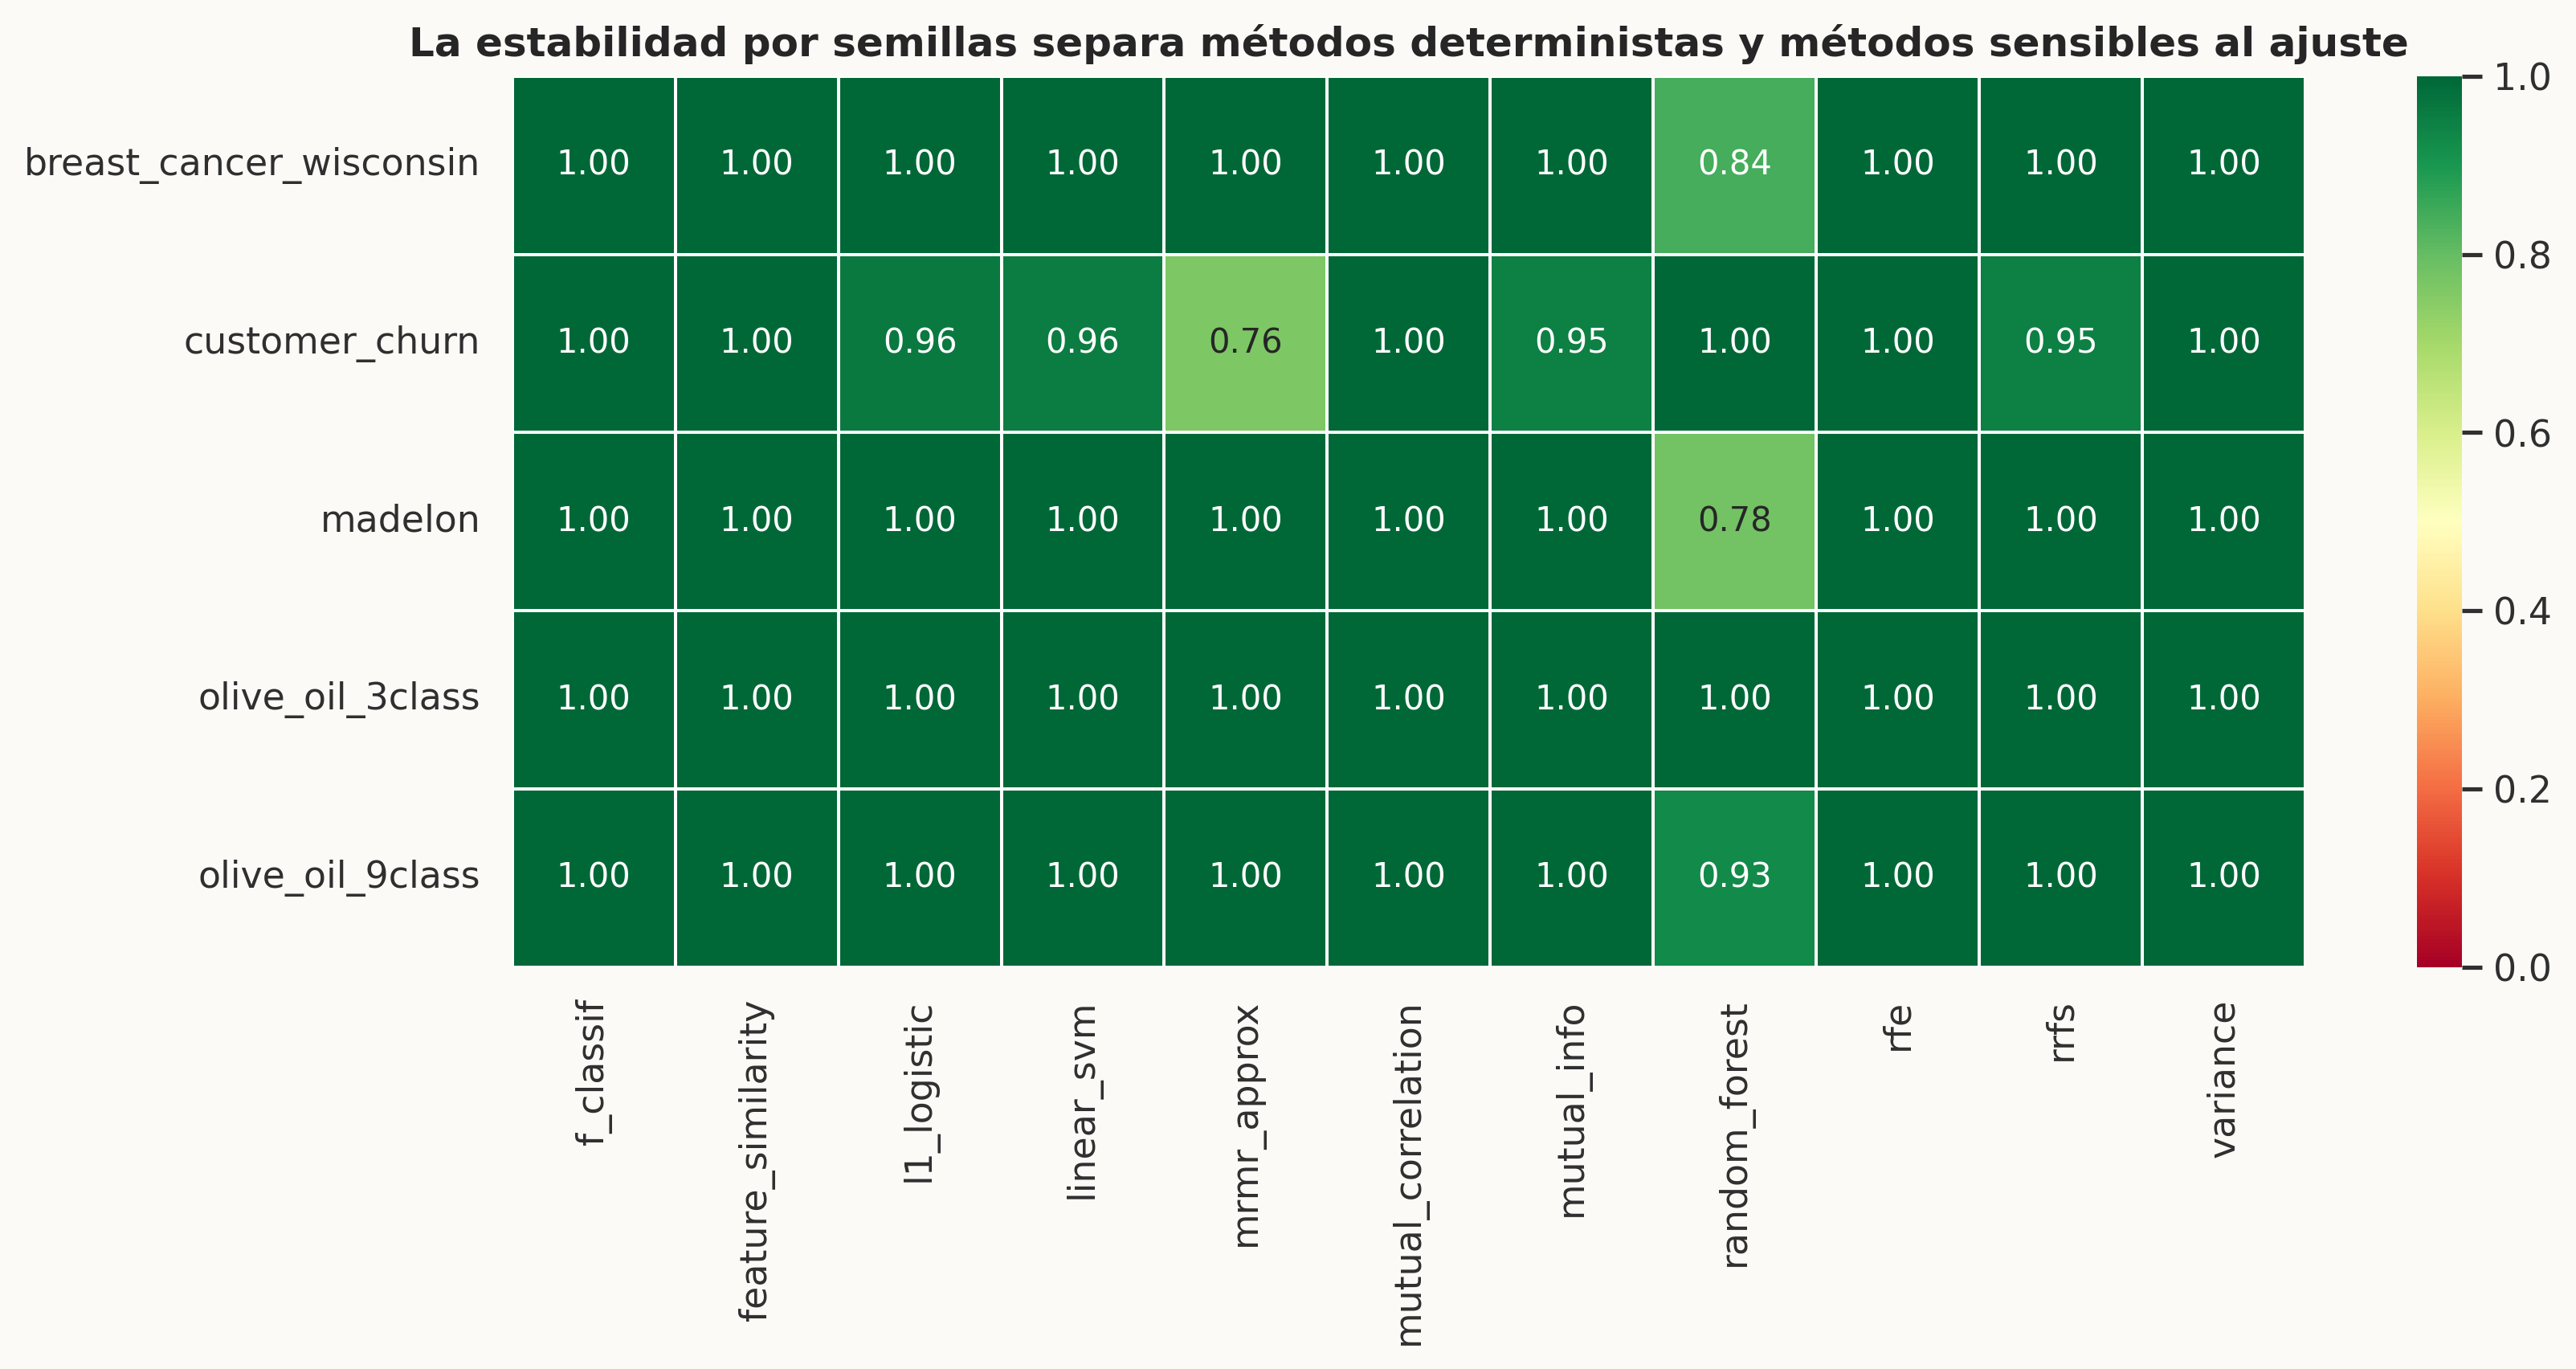

In [18]:
figuras = []

ruta_estabilidad = fs.plot_estabilidad(jaccard)
figuras.append({"family_id": "fase5_estabilidad_jaccard", "tier": 2, "question": "¿Qué métodos son estables entre semillas en cada dataset?", "visual_family": "heatmap anotado", "decision": "matriz dataset-método porque la comparación cruzada es el mensaje", "png_path": str(ruta_estabilidad)})
mostrar_png(ruta_estabilidad)

La figura de estabilidad resume 3 semillas por método con ranking. Esta lectura no aparece en el ranking de una sola semilla: necesita comparar subconjuntos repetidos y medir su Jaccard medio entre pares.

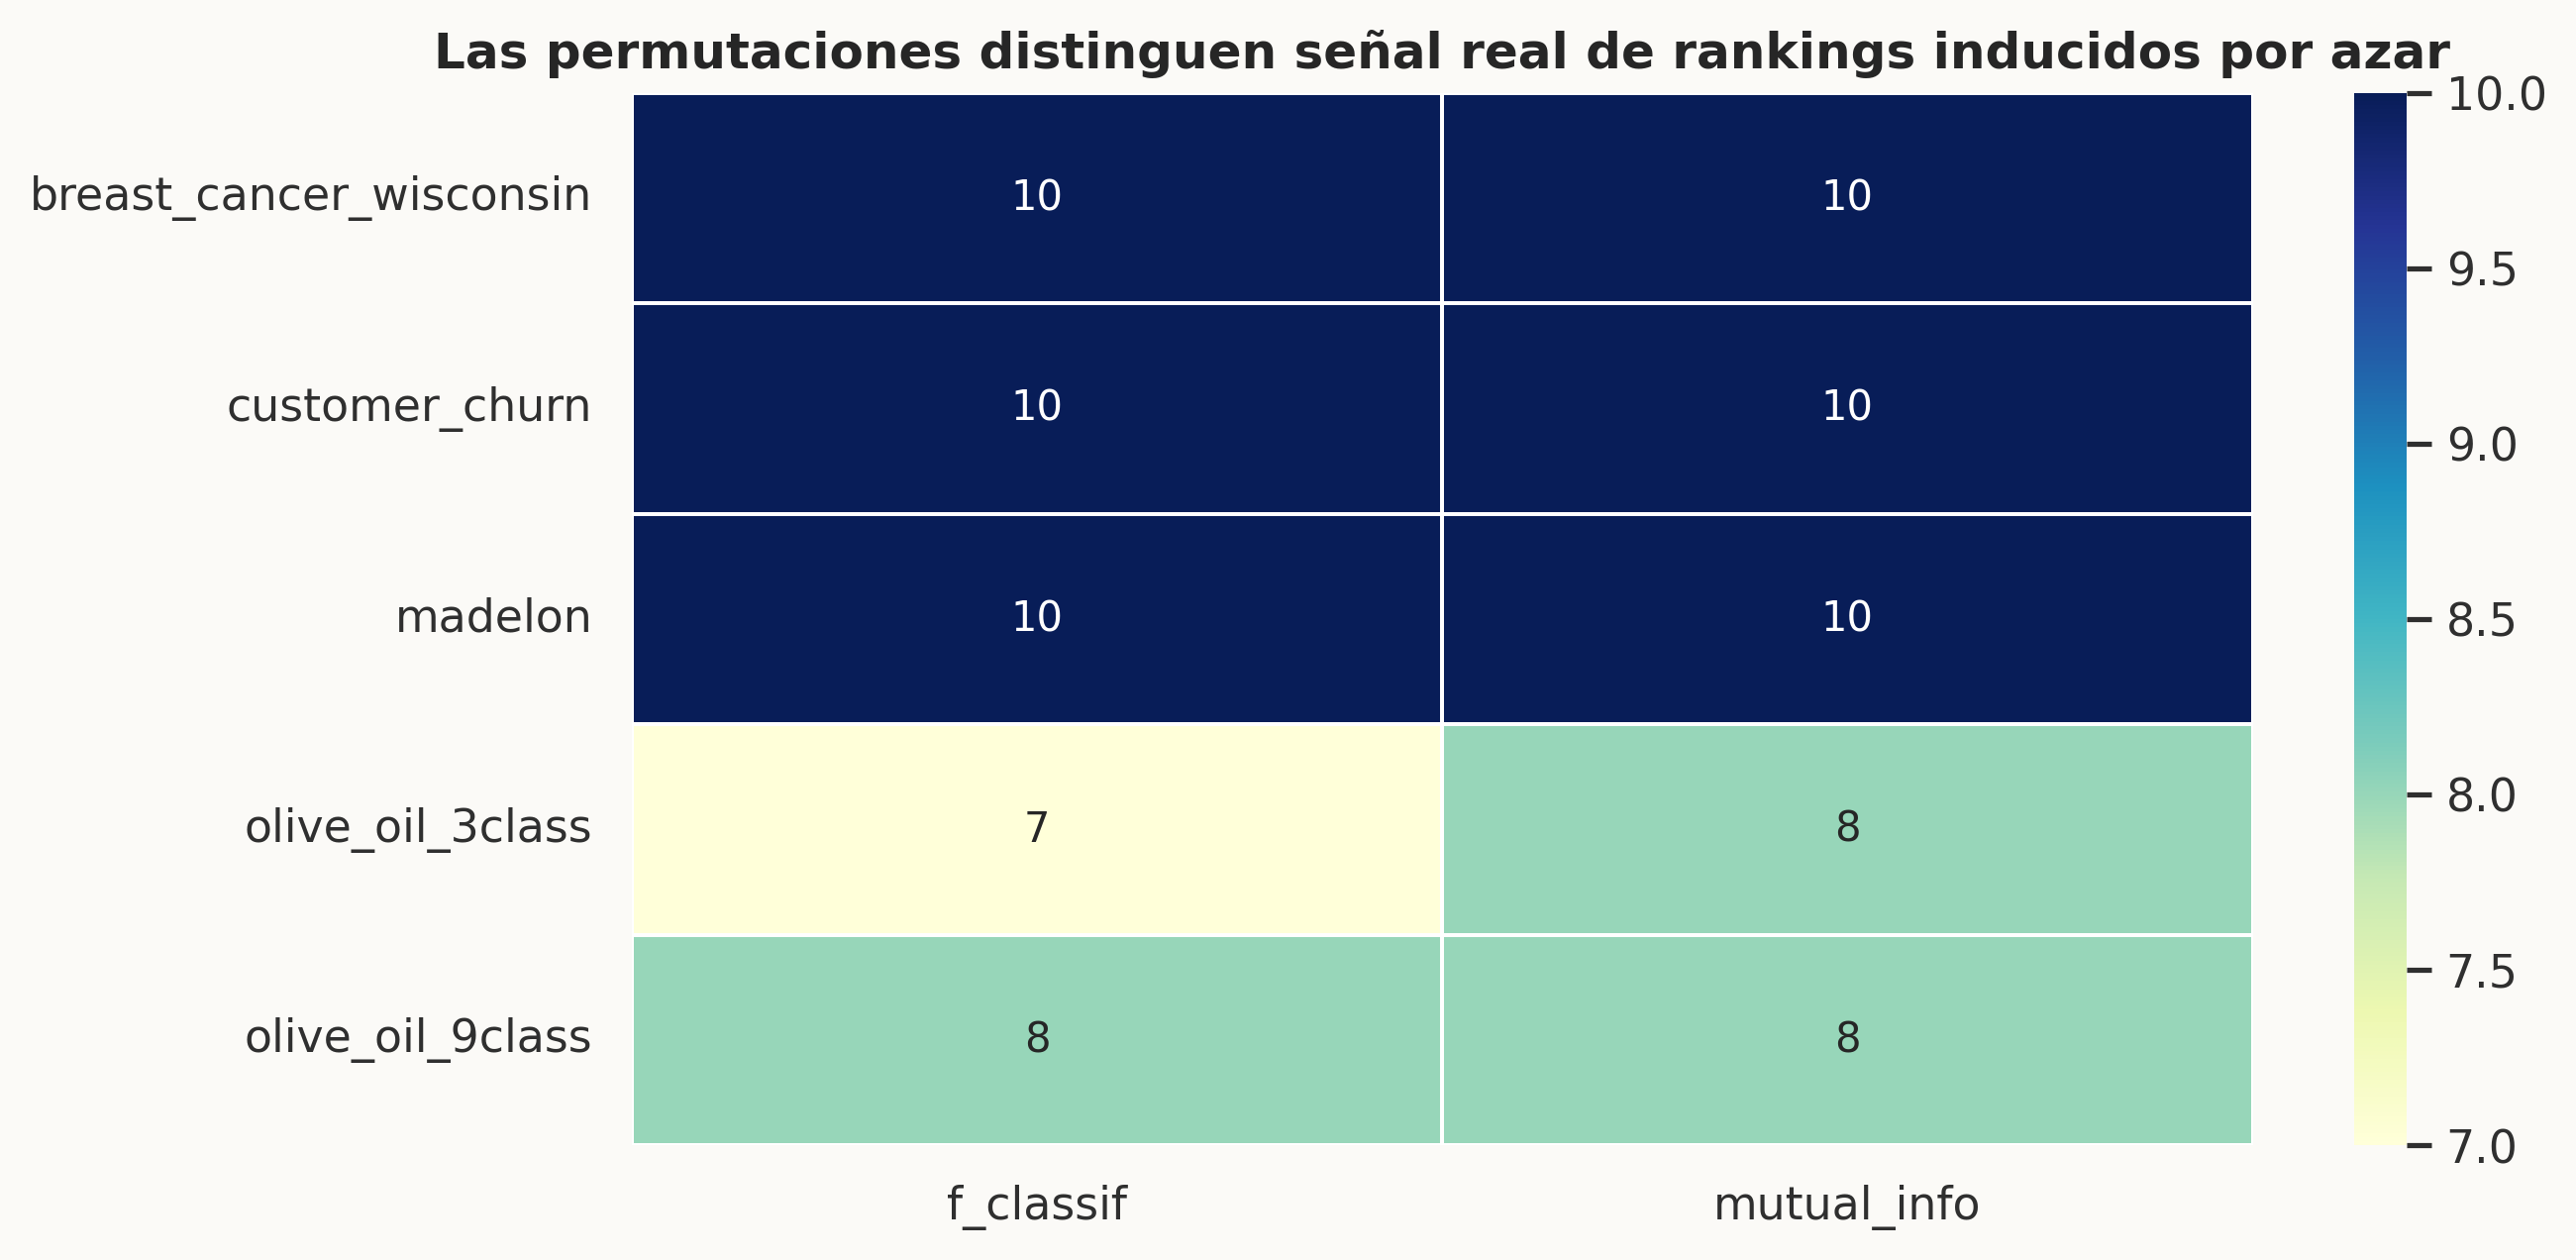

In [19]:
ruta_permutaciones = fs.plot_permutaciones(permutation_summary)
figuras.append({"family_id": "fase5_permutaciones_target", "tier": 2, "question": "¿Qué métodos separan variables reales del nulo por permutación?", "visual_family": "heatmap anotado", "decision": "matriz compacta para contar variables sobre p95 nulo", "png_path": str(ruta_permutaciones)})
mostrar_png(ruta_permutaciones)

La figura de permutaciones concentra el contraste real-nulo por dataset y método. Los valores altos señalan rankings supervisados con más variables por encima del percentil 95 nulo; los valores bajos obligan a interpretar el score como débil frente al azar inducido.

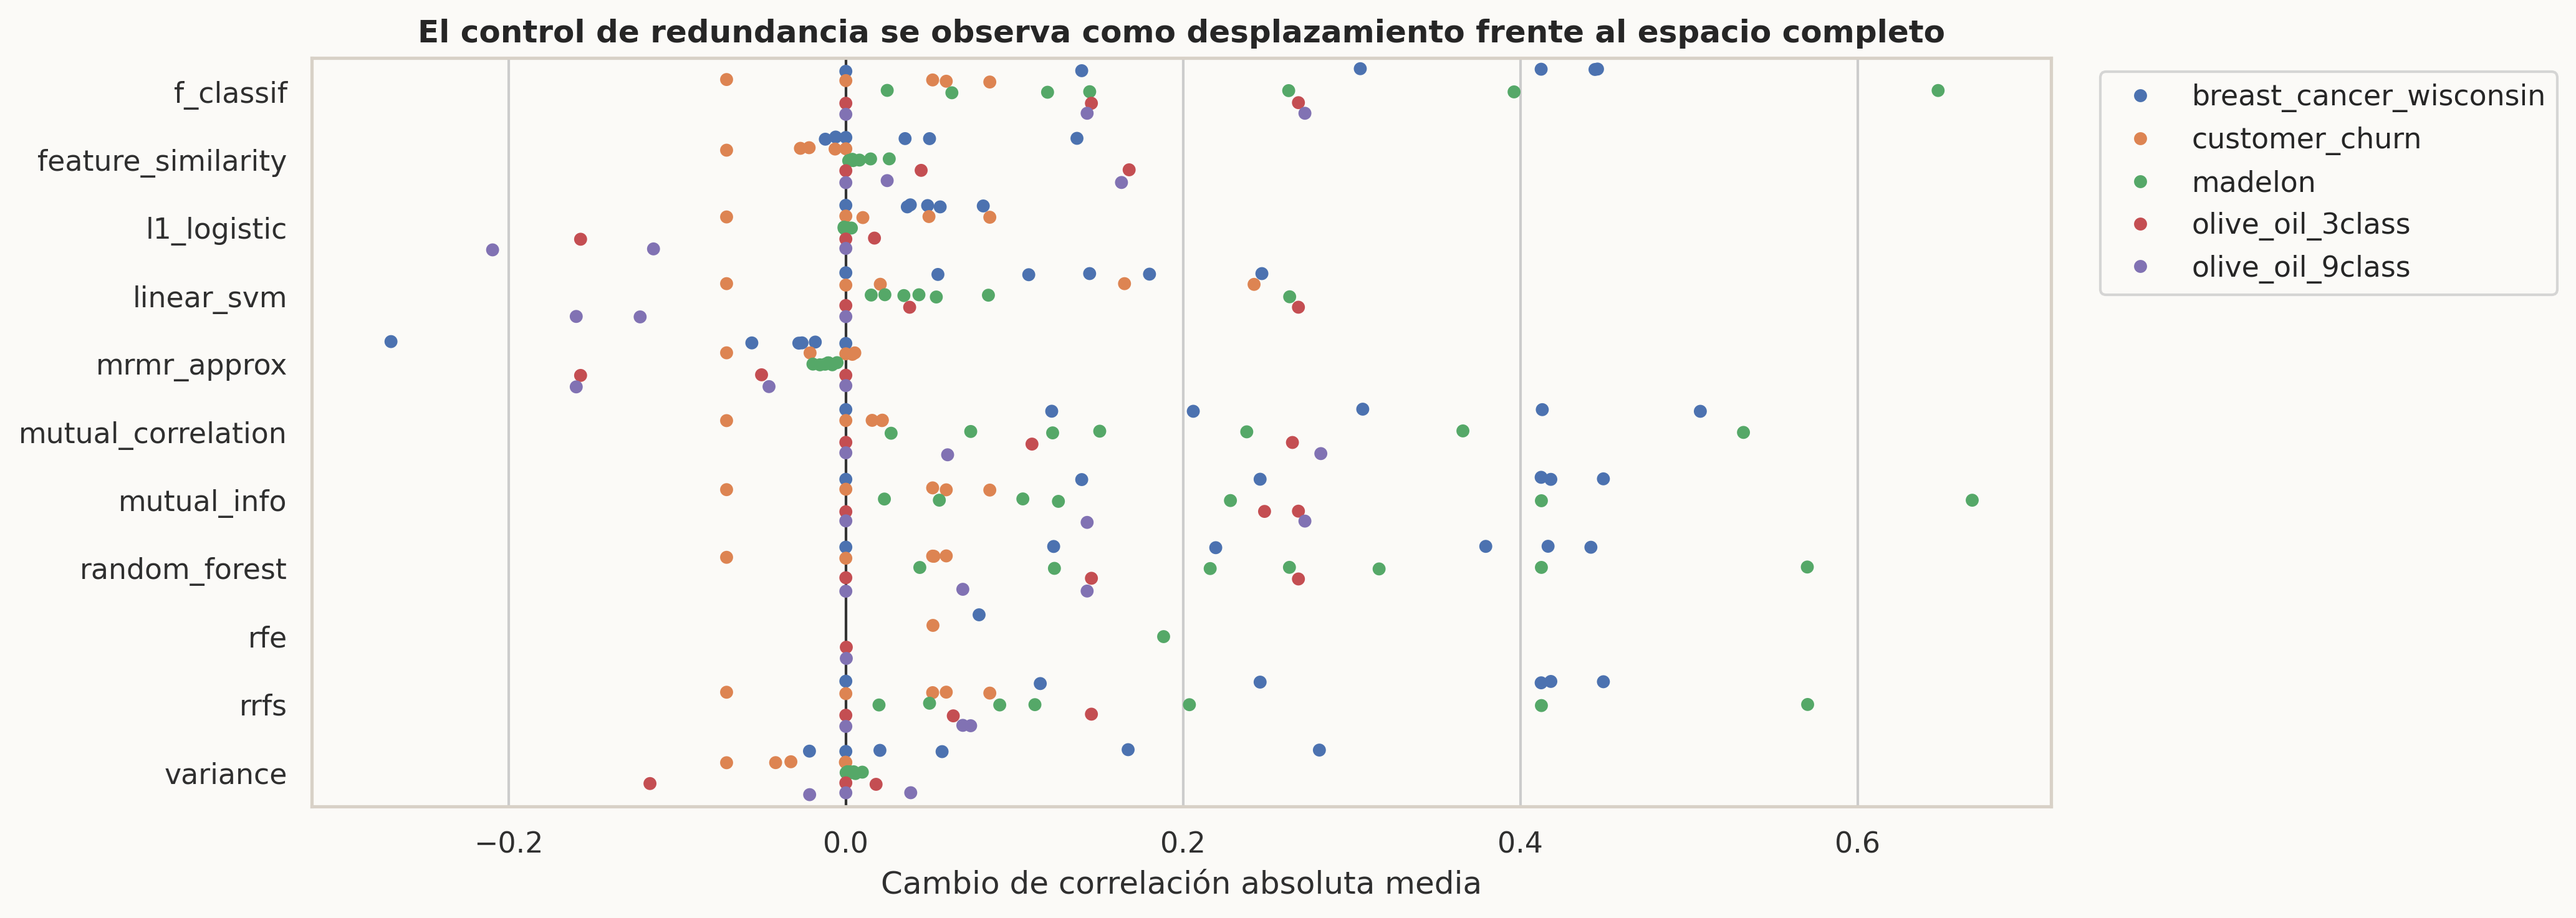

In [20]:
ruta_redundancia = fs.plot_redundancia(redundancia)
figuras.append({"family_id": "fase5_redundancia_interna", "tier": 2, "question": "¿La selección reduce o concentra redundancia respecto al espacio completo?", "visual_family": "dot plot con línea cero", "decision": "puntos por dataset para preservar signo y dispersión", "png_path": str(ruta_redundancia)})
mostrar_png(ruta_redundancia)

La línea vertical en 0 separa reducción y concentración de redundancia. Los puntos a la izquierda muestran subconjuntos menos redundantes que el espacio completo; los puntos a la derecha concentran variables más parecidas entre sí.

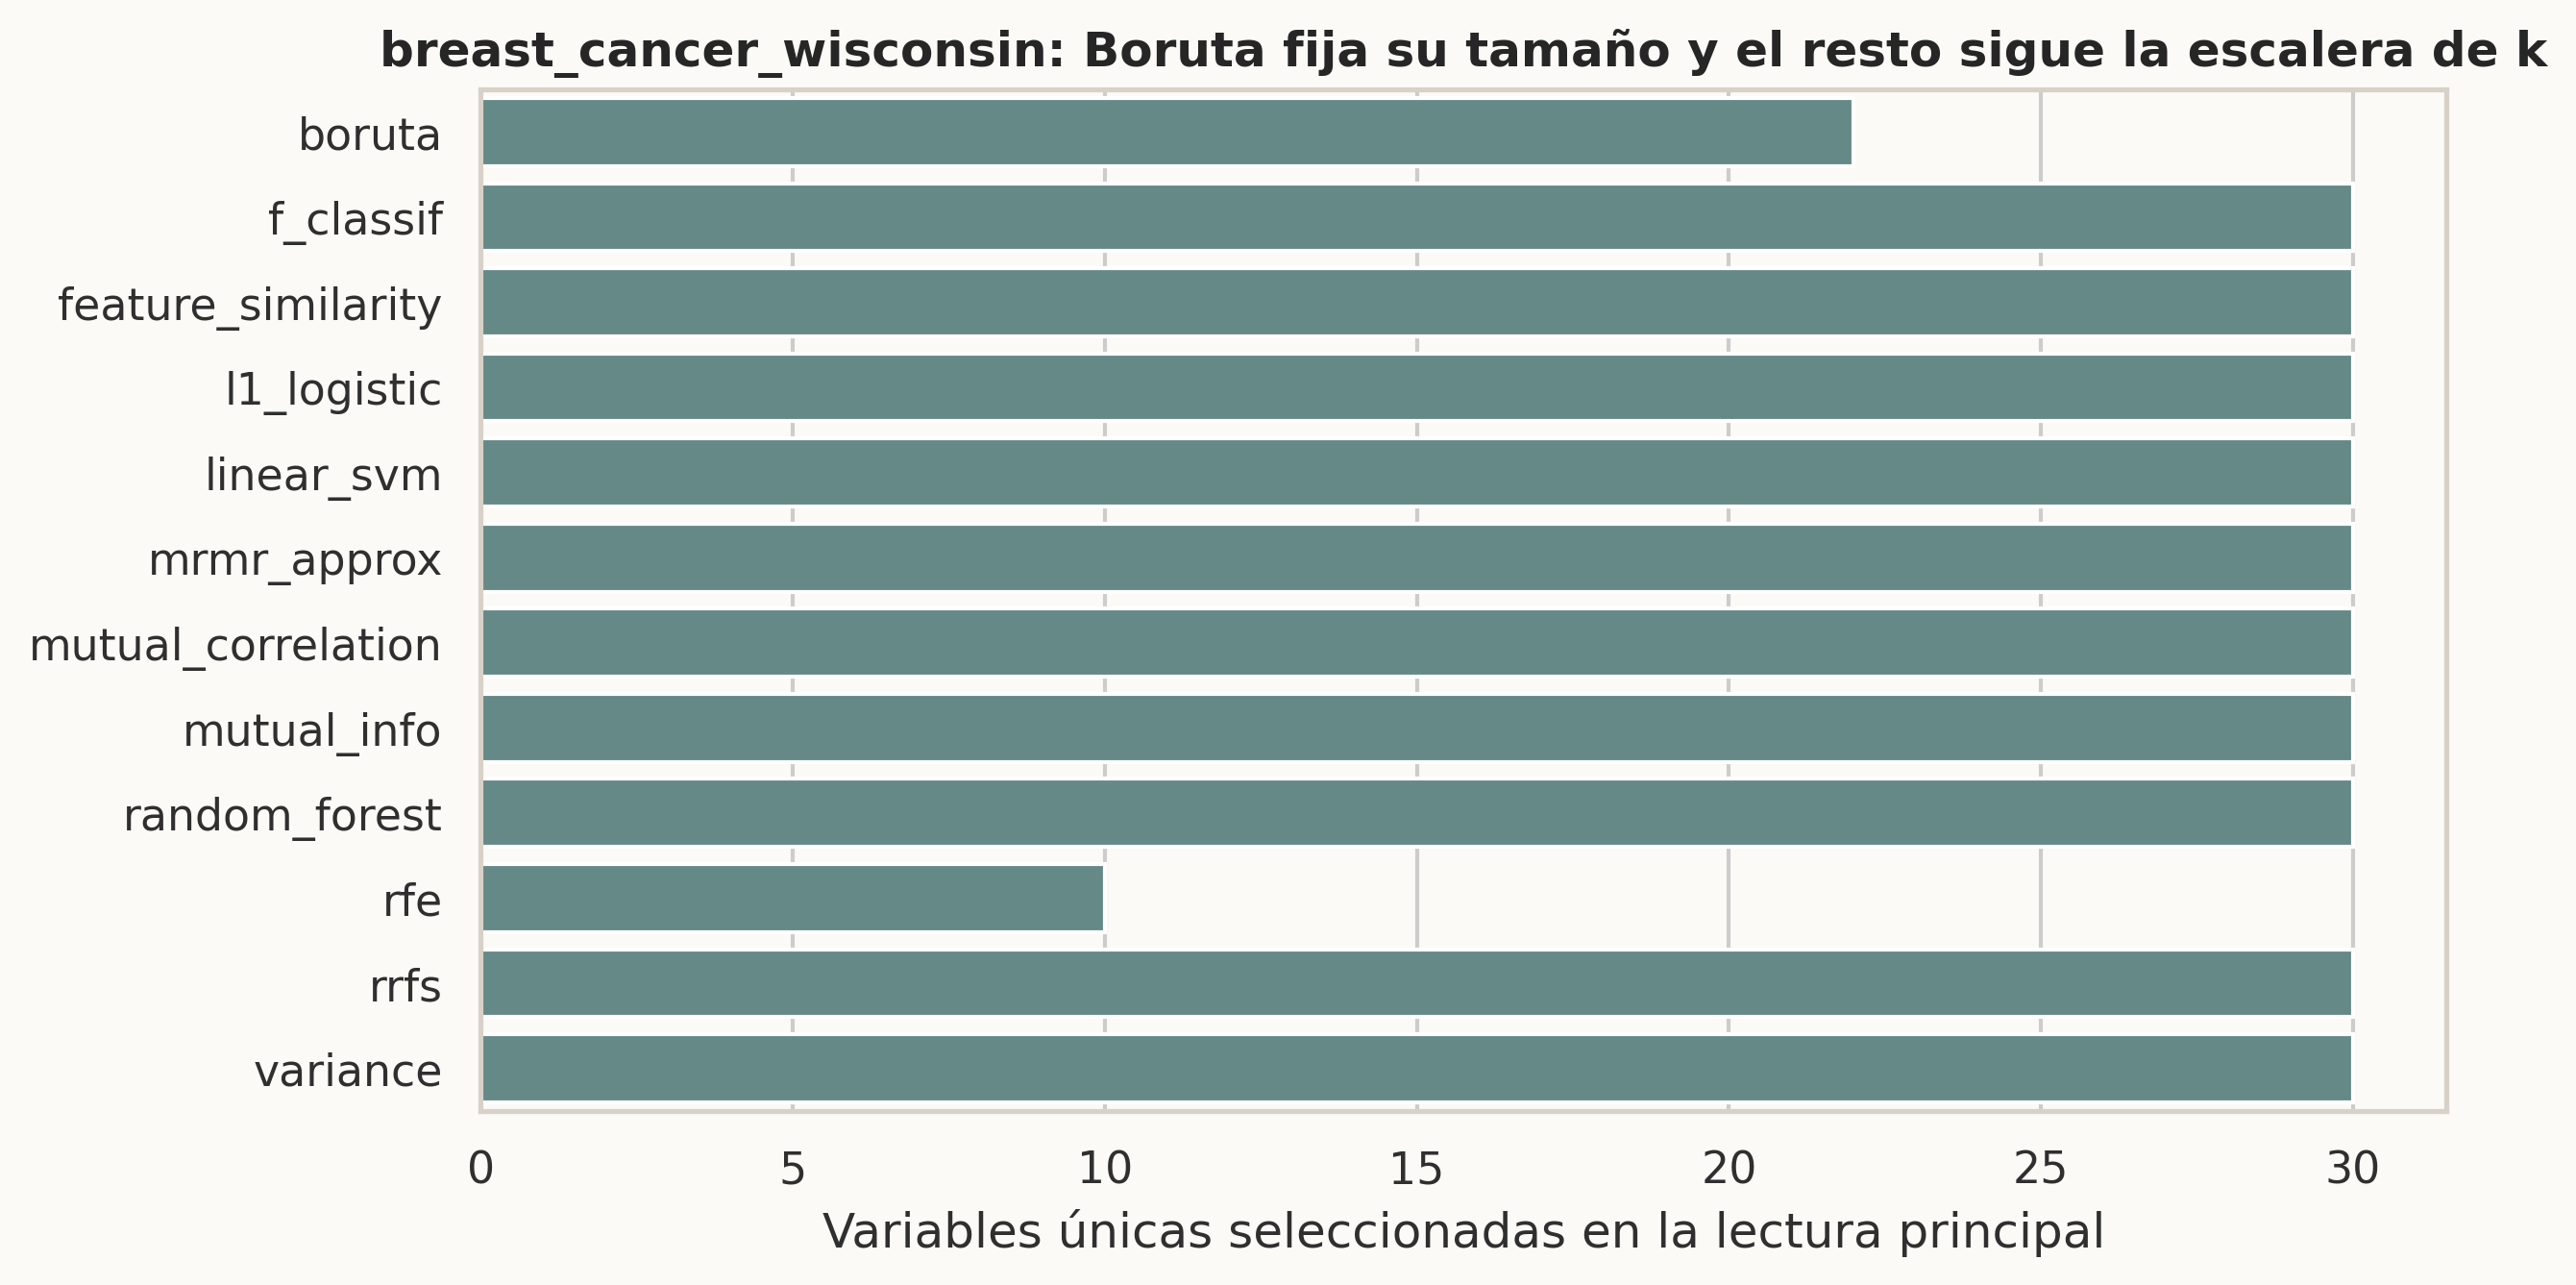

In [21]:
ruta_roster_breast_cancer_wisconsin = fs.plot_roster_dataset(rankings, "breast_cancer_wisconsin")
figuras.append({"family_id": "fase5_comparacion_roster_dataset", "tier": 0, "question": "¿Cómo cambia el tamaño seleccionado entre métodos para un dataset?", "visual_family": "barras horizontales", "decision": "reusa familia por dataset con escala local", "png_path": str(ruta_roster_breast_cancer_wisconsin)})
mostrar_png(ruta_roster_breast_cancer_wisconsin, ancho=780)

En `breast_cancer_wisconsin`, la figura resume 12 métodos y deja visible si Boruta se sitúa por encima o por debajo de los cortes top-k. El contraste aporta una lectura de tamaño que la tabla de variables no muestra de forma inmediata.

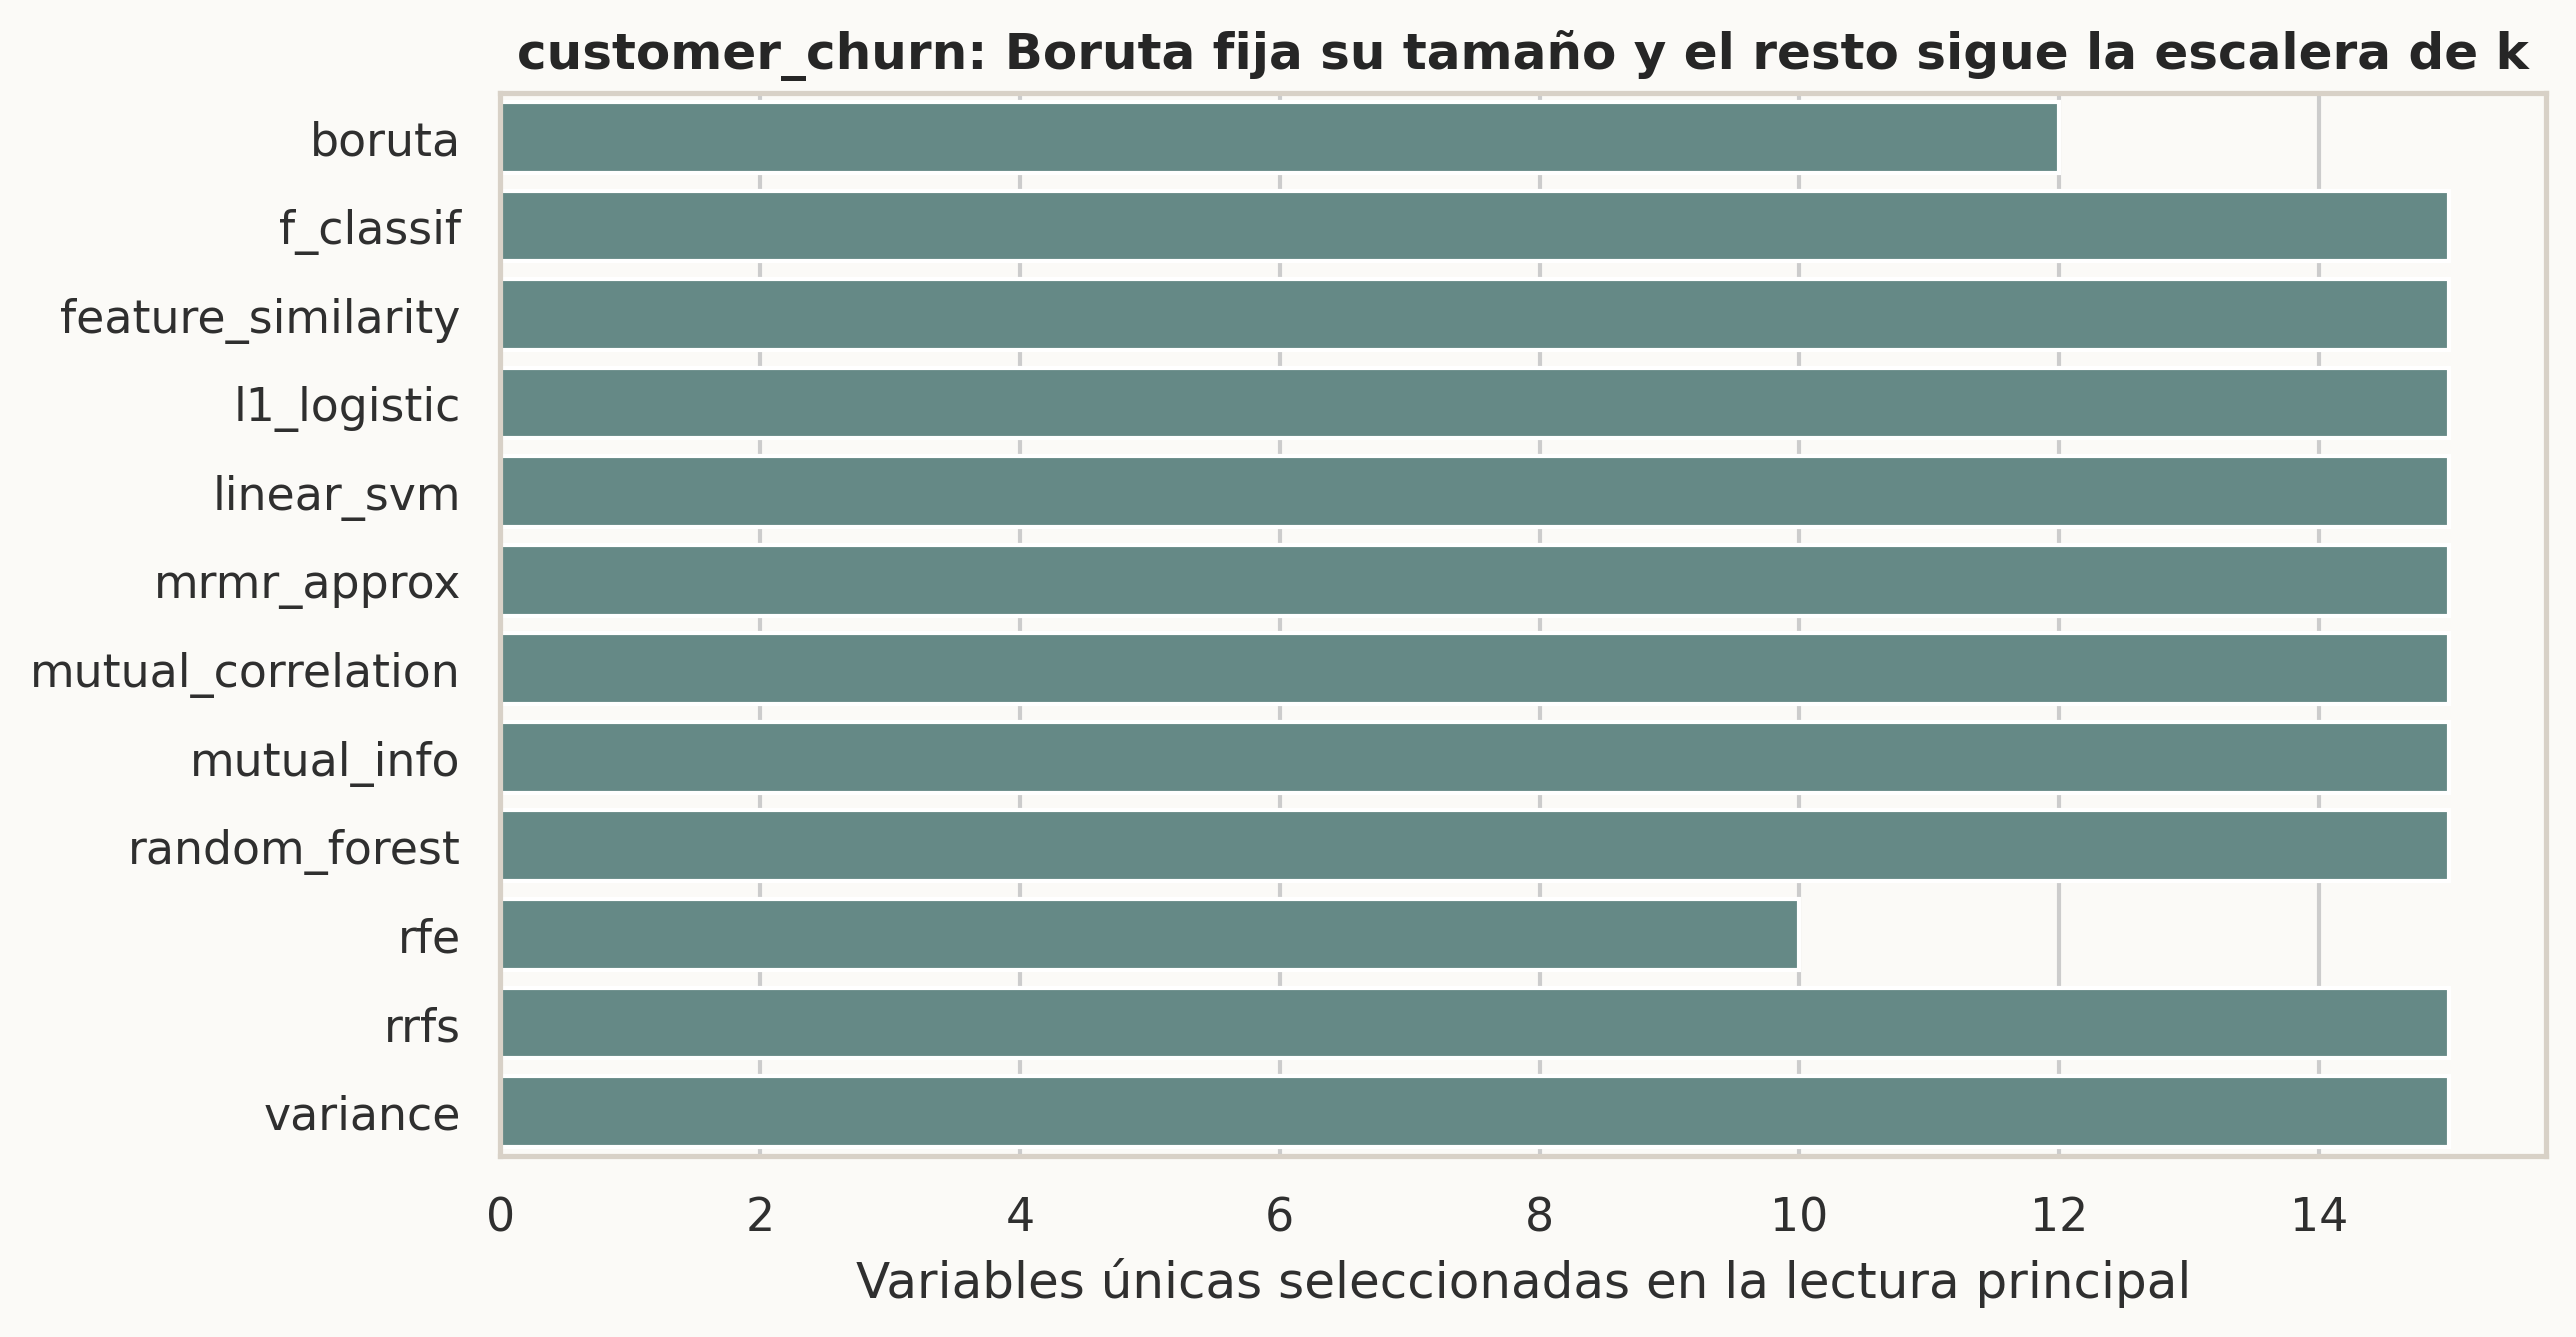

In [22]:
ruta_roster_customer_churn = fs.plot_roster_dataset(rankings, "customer_churn")
figuras.append({"family_id": "fase5_comparacion_roster_dataset", "tier": 0, "question": "¿Cómo cambia el tamaño seleccionado entre métodos para un dataset?", "visual_family": "barras horizontales", "decision": "reusa familia por dataset con escala local", "png_path": str(ruta_roster_customer_churn)})
mostrar_png(ruta_roster_customer_churn, ancho=780)

En `customer_churn`, la figura compara 12 decisiones sobre un espacio de 15 variables. El tamaño confirmado de Boruta se interpreta como referencia all-relevant, mientras que los métodos con ranking se leen por cortes de k.

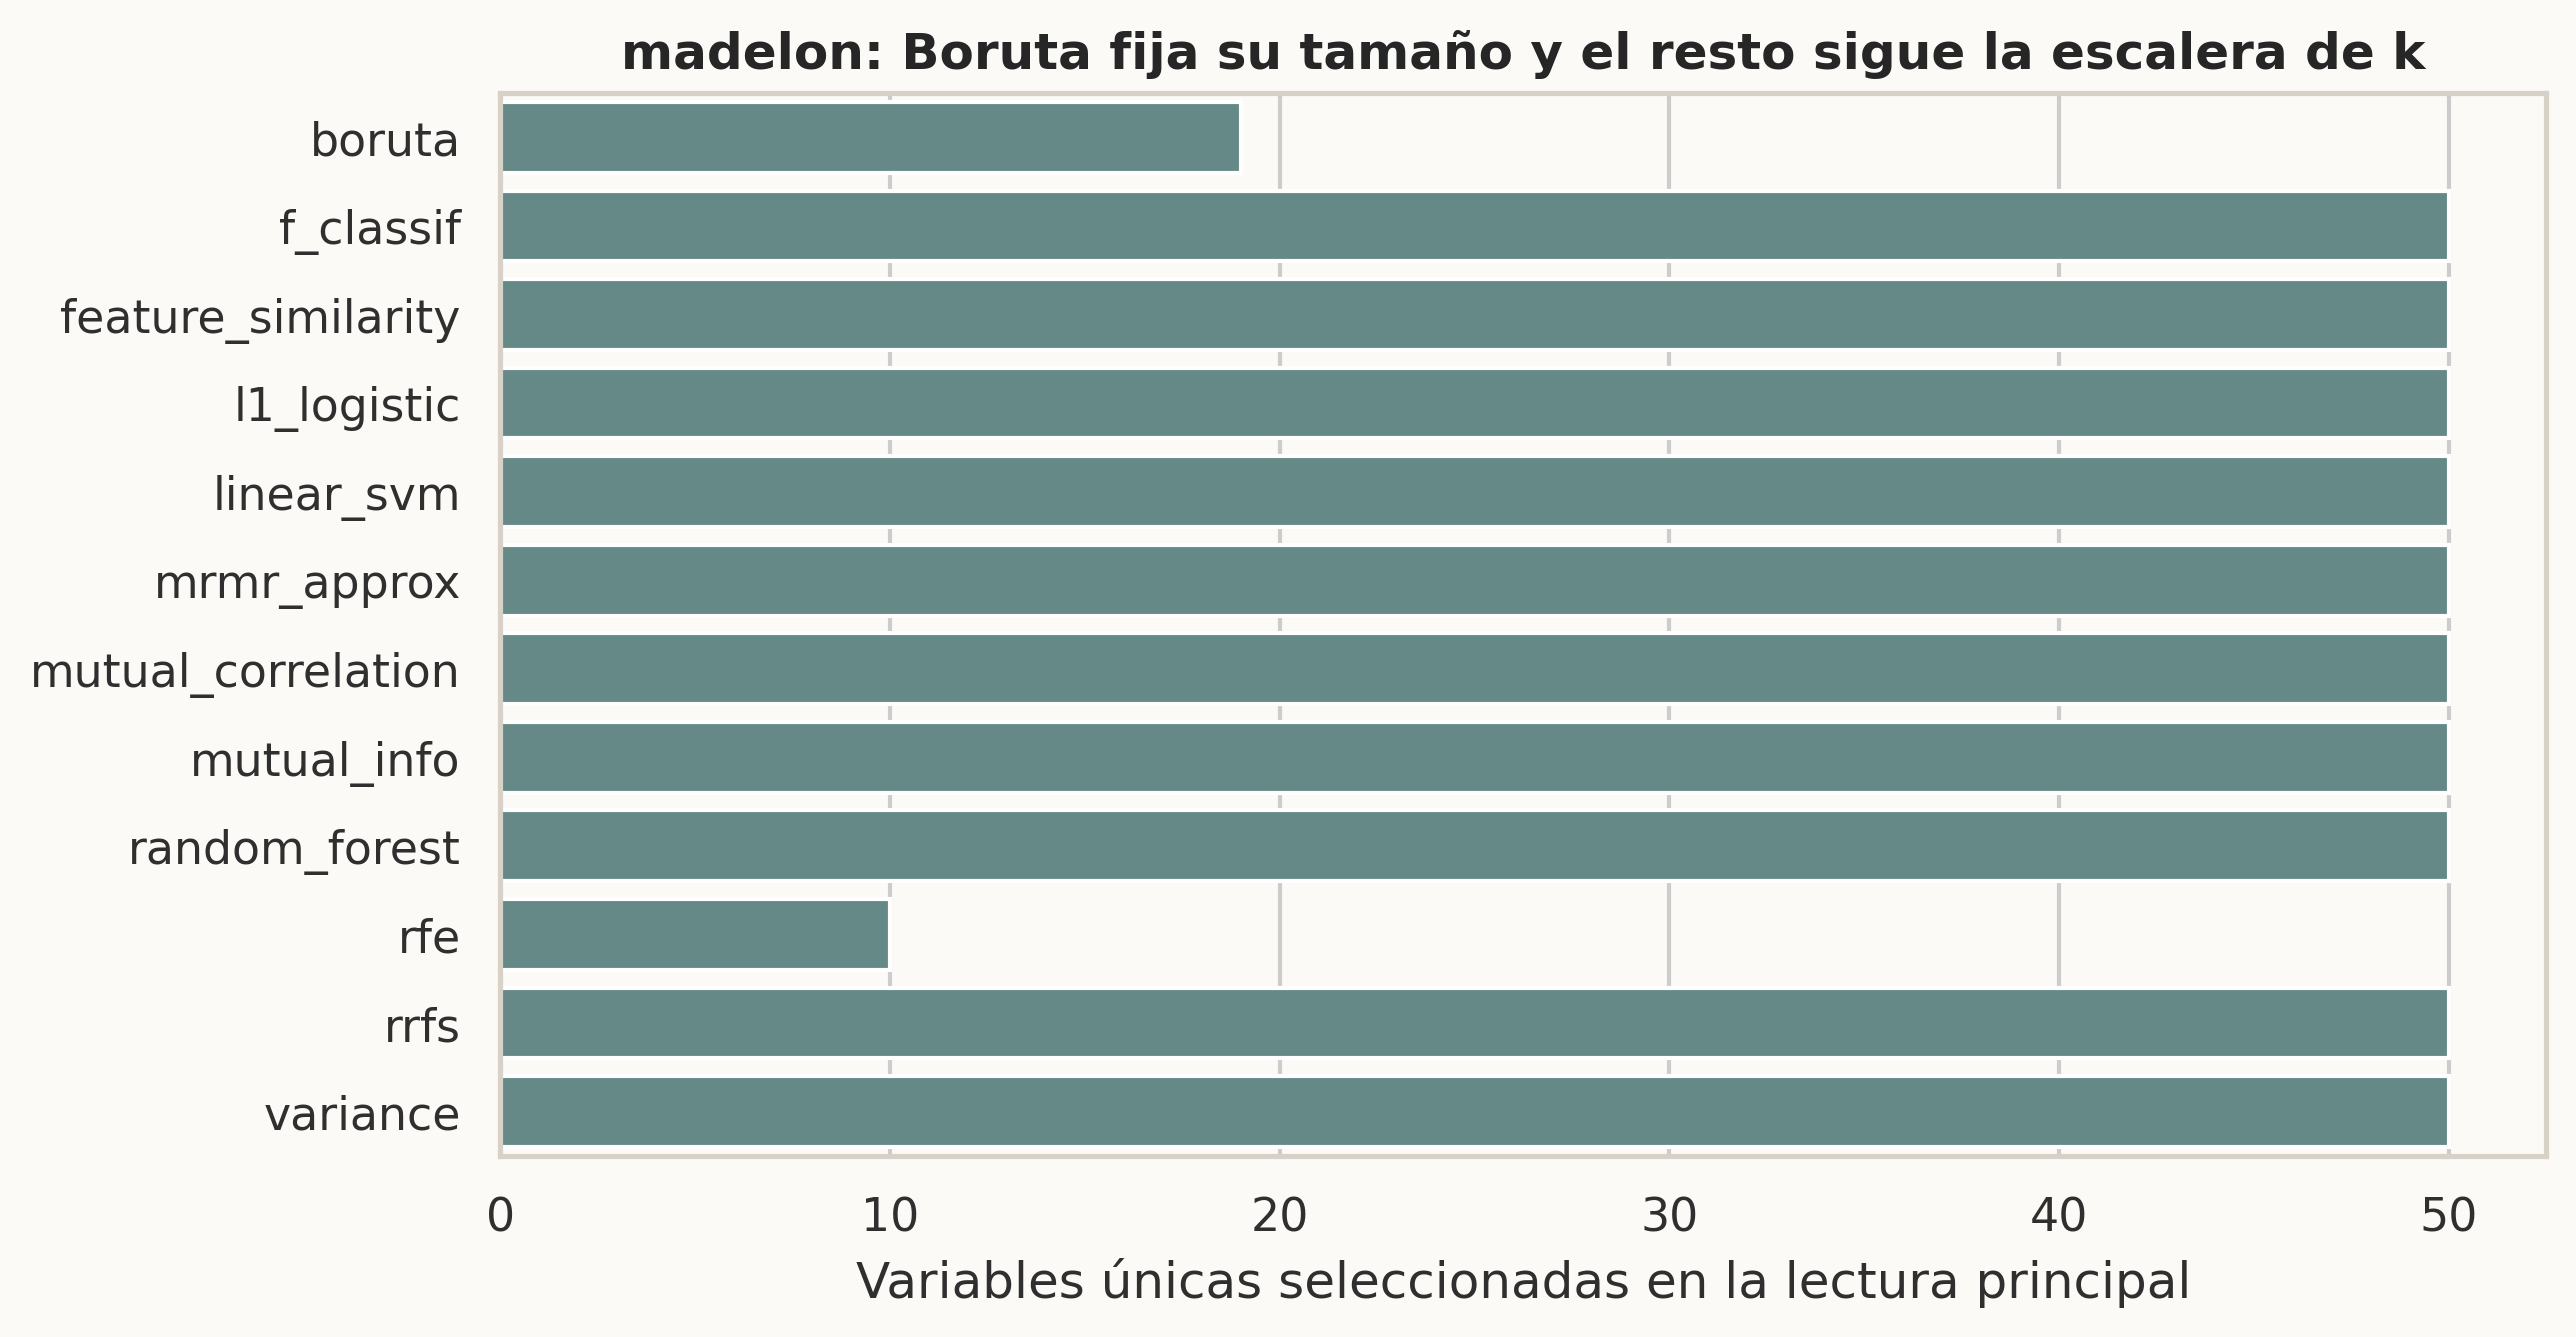

In [23]:
ruta_roster_madelon = fs.plot_roster_dataset(rankings, "madelon")
figuras.append({"family_id": "fase5_comparacion_roster_dataset", "tier": 0, "question": "¿Cómo cambia el tamaño seleccionado entre métodos para un dataset?", "visual_family": "barras horizontales", "decision": "reusa familia por dataset con escala local", "png_path": str(ruta_roster_madelon)})
mostrar_png(ruta_roster_madelon, ancho=780)

En `madelon`, la figura comprime la comparación de 12 métodos sobre 500 variables. La distancia entre el tamaño de Boruta y los cortes pequeños ayuda a leer cuánto cribado exige el problema sintético.

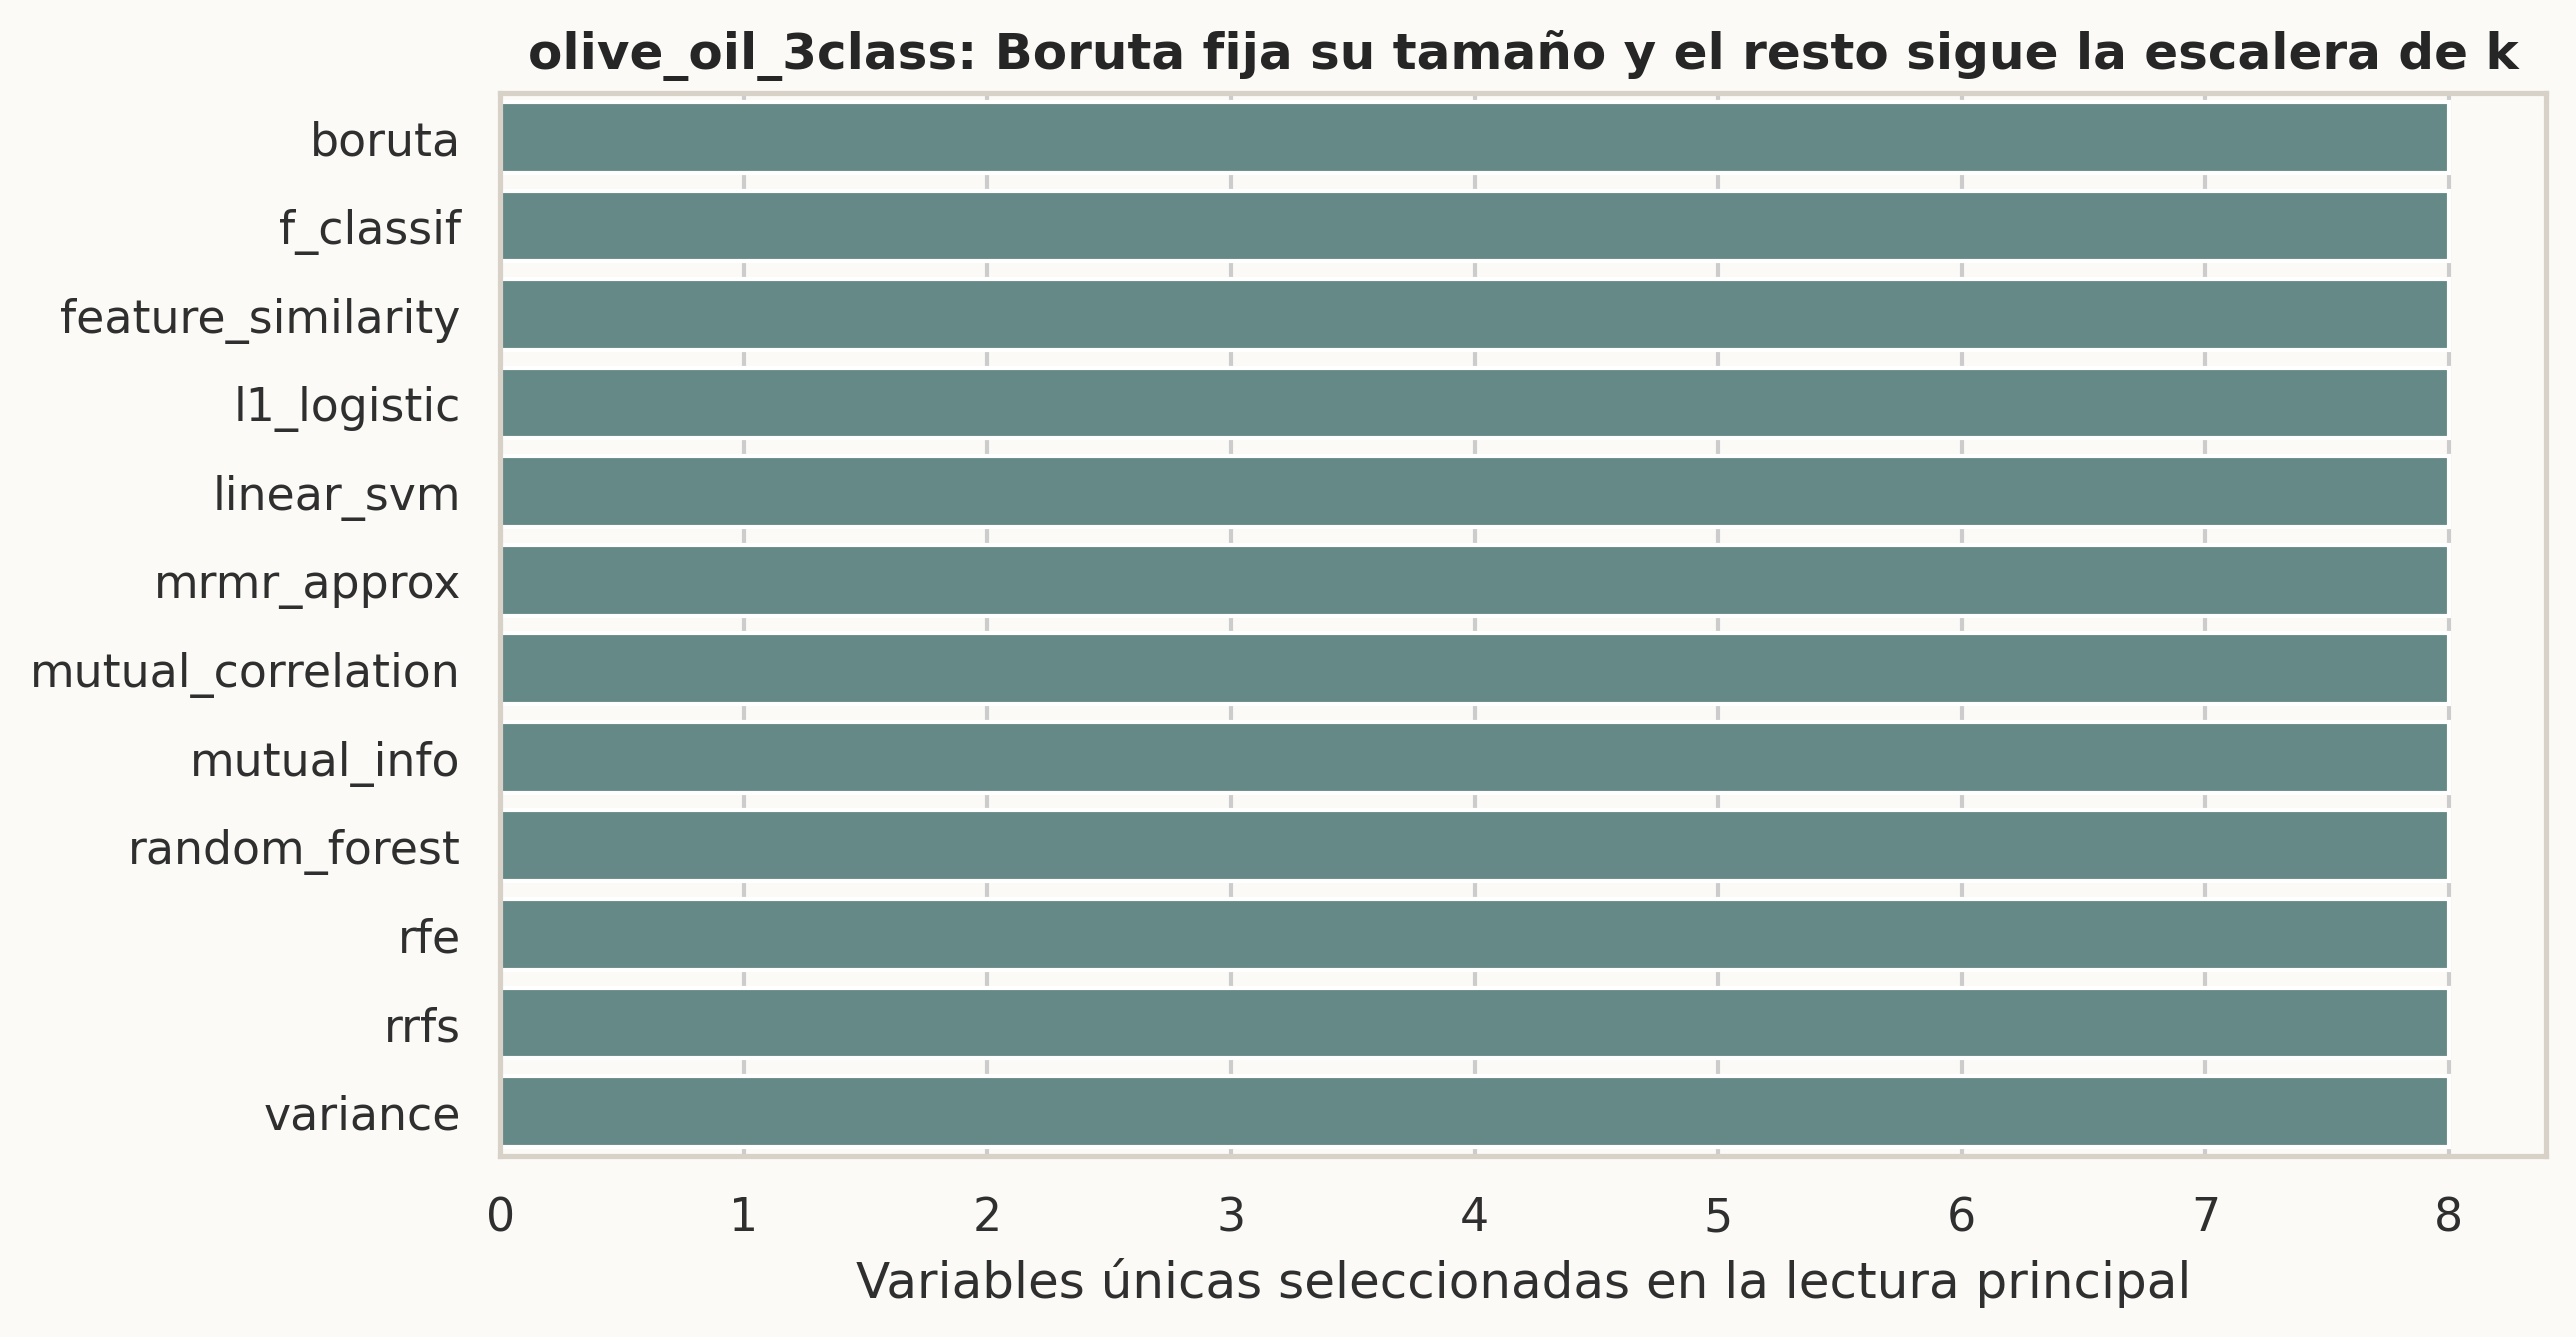

In [24]:
ruta_roster_olive_oil_3class = fs.plot_roster_dataset(rankings, "olive_oil_3class")
figuras.append({"family_id": "fase5_comparacion_roster_dataset", "tier": 0, "question": "¿Cómo cambia el tamaño seleccionado entre métodos para un dataset?", "visual_family": "barras horizontales", "decision": "reusa familia por dataset con escala local", "png_path": str(ruta_roster_olive_oil_3class)})
mostrar_png(ruta_roster_olive_oil_3class, ancho=780)

En `olive_oil_3class`, la figura muestra que 8 variables dejan poco margen para reducciones extremas. Por eso el interés está en qué métodos evitan redundancia, no solo en cuántas columnas retienen.

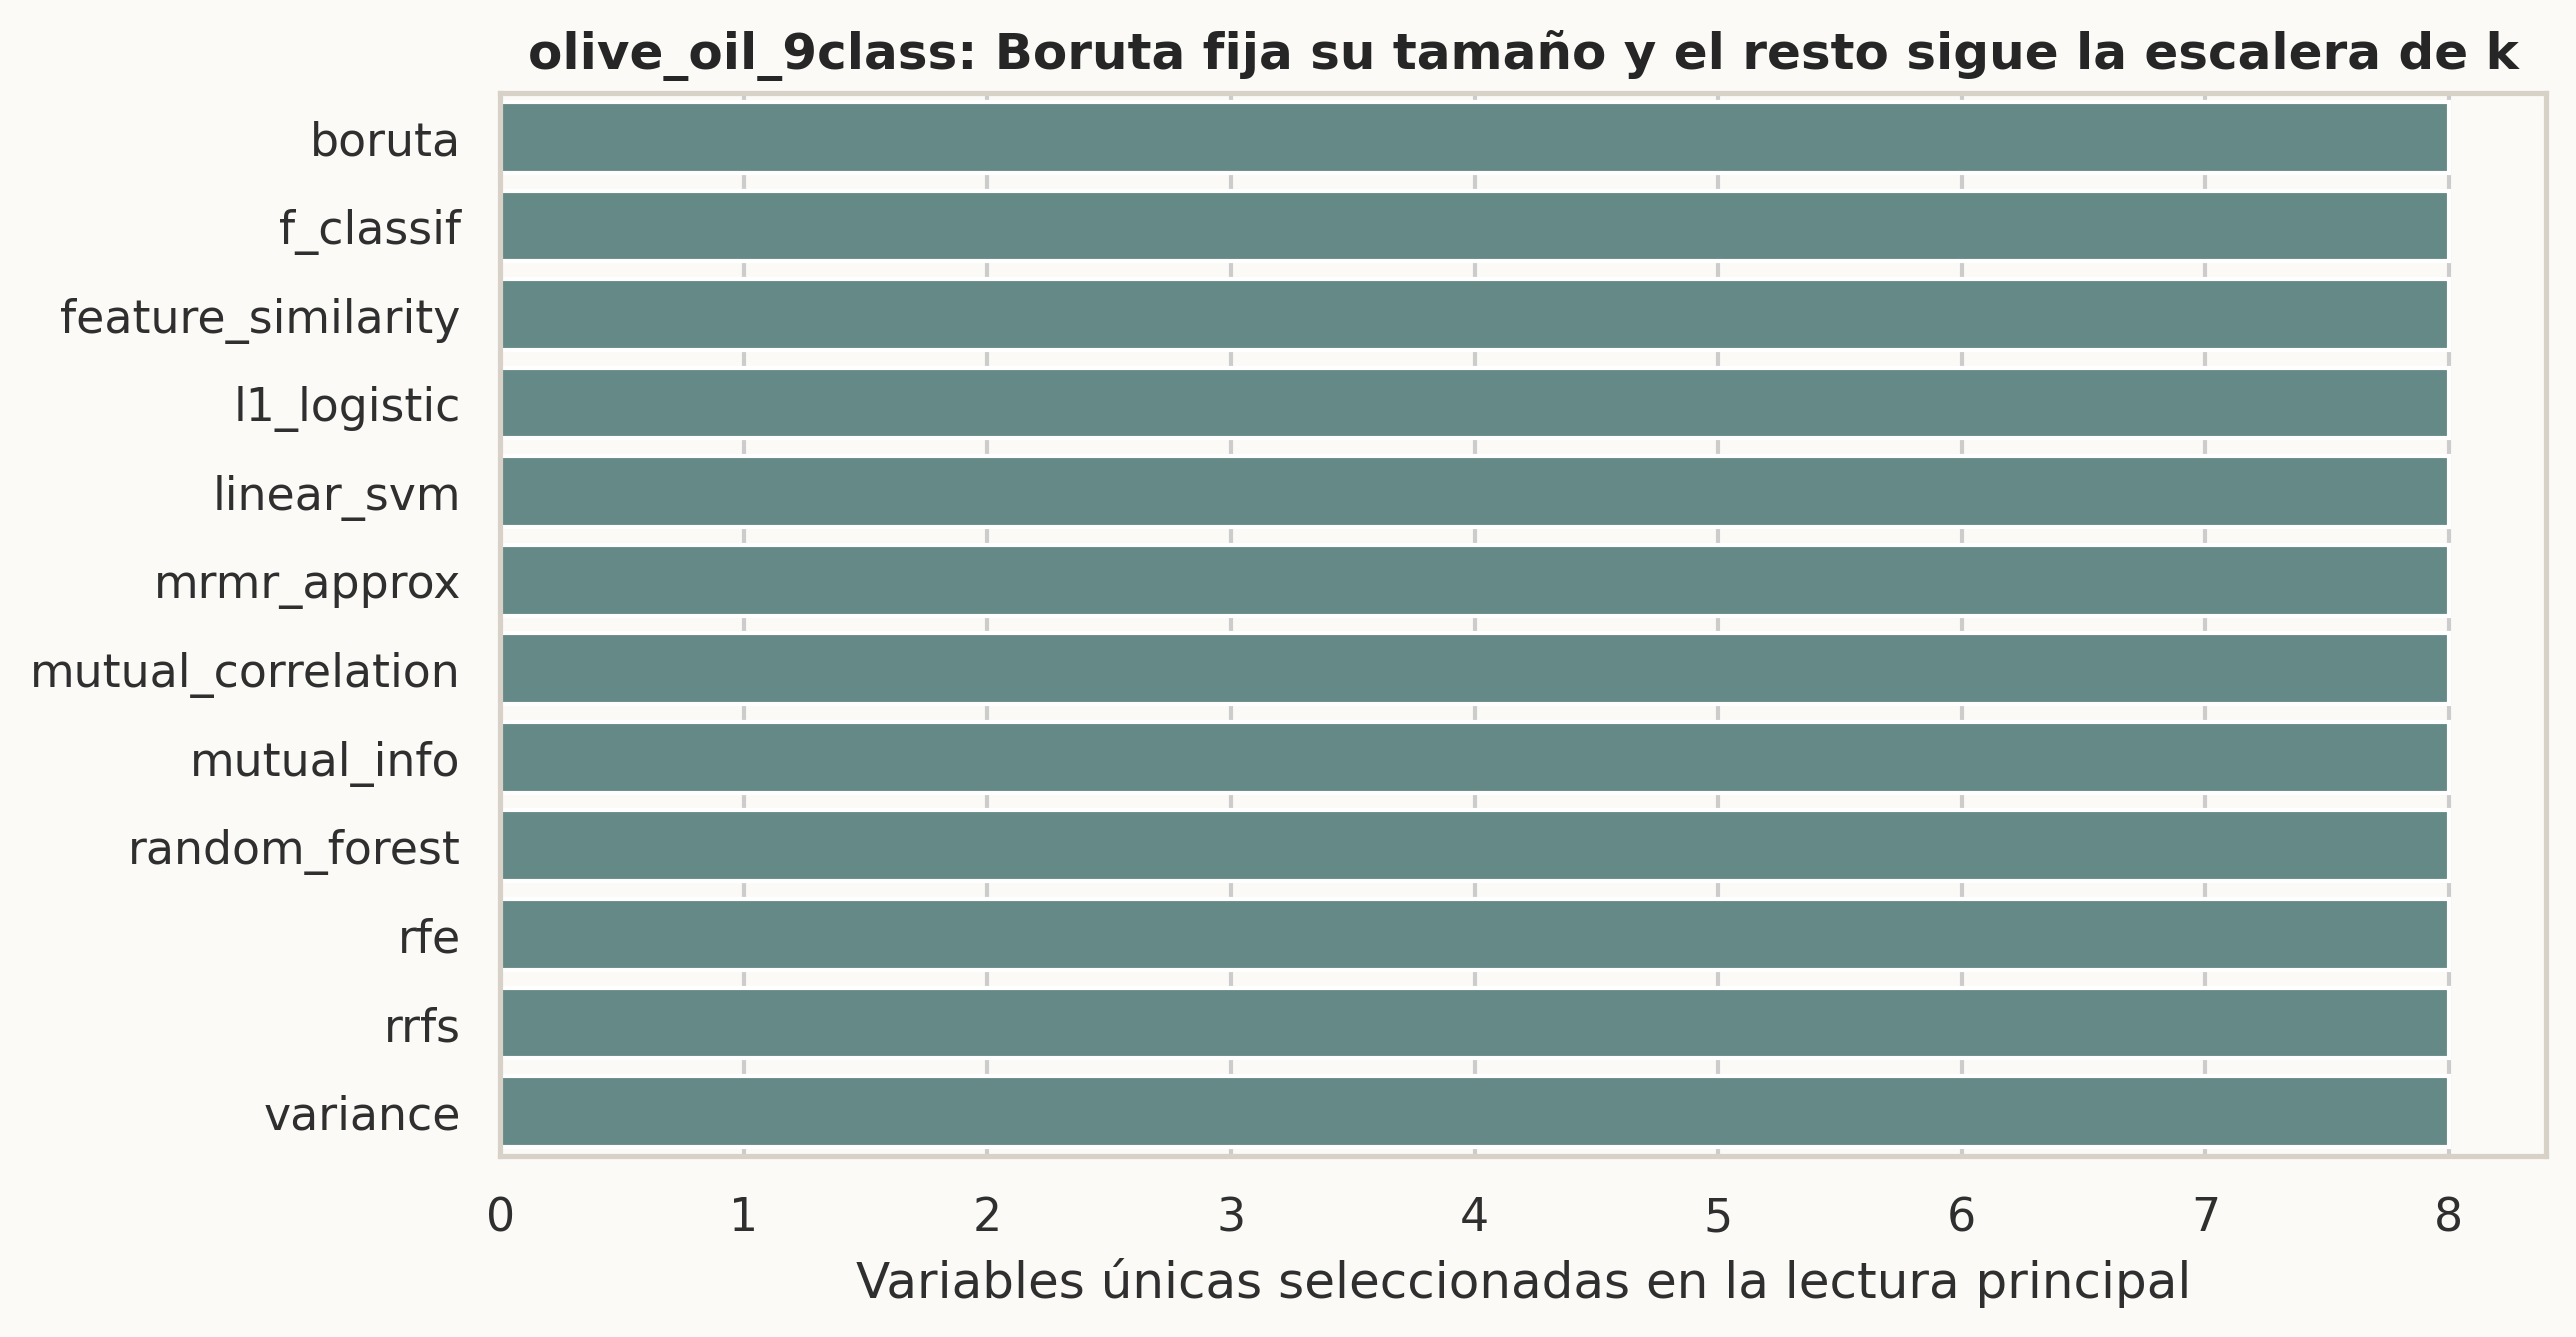

In [25]:
ruta_roster_olive_oil_9class = fs.plot_roster_dataset(rankings, "olive_oil_9class")
figuras.append({"family_id": "fase5_comparacion_roster_dataset", "tier": 0, "question": "¿Cómo cambia el tamaño seleccionado entre métodos para un dataset?", "visual_family": "barras horizontales", "decision": "reusa familia por dataset con escala local", "png_path": str(ruta_roster_olive_oil_9class)})
mostrar_png(ruta_roster_olive_oil_9class, ancho=780)

En `olive_oil_9class`, los mismos 8 predictores se comparan bajo un target más fino. La figura actúa como control de tamaño antes de interpretar estabilidad y permutaciones.

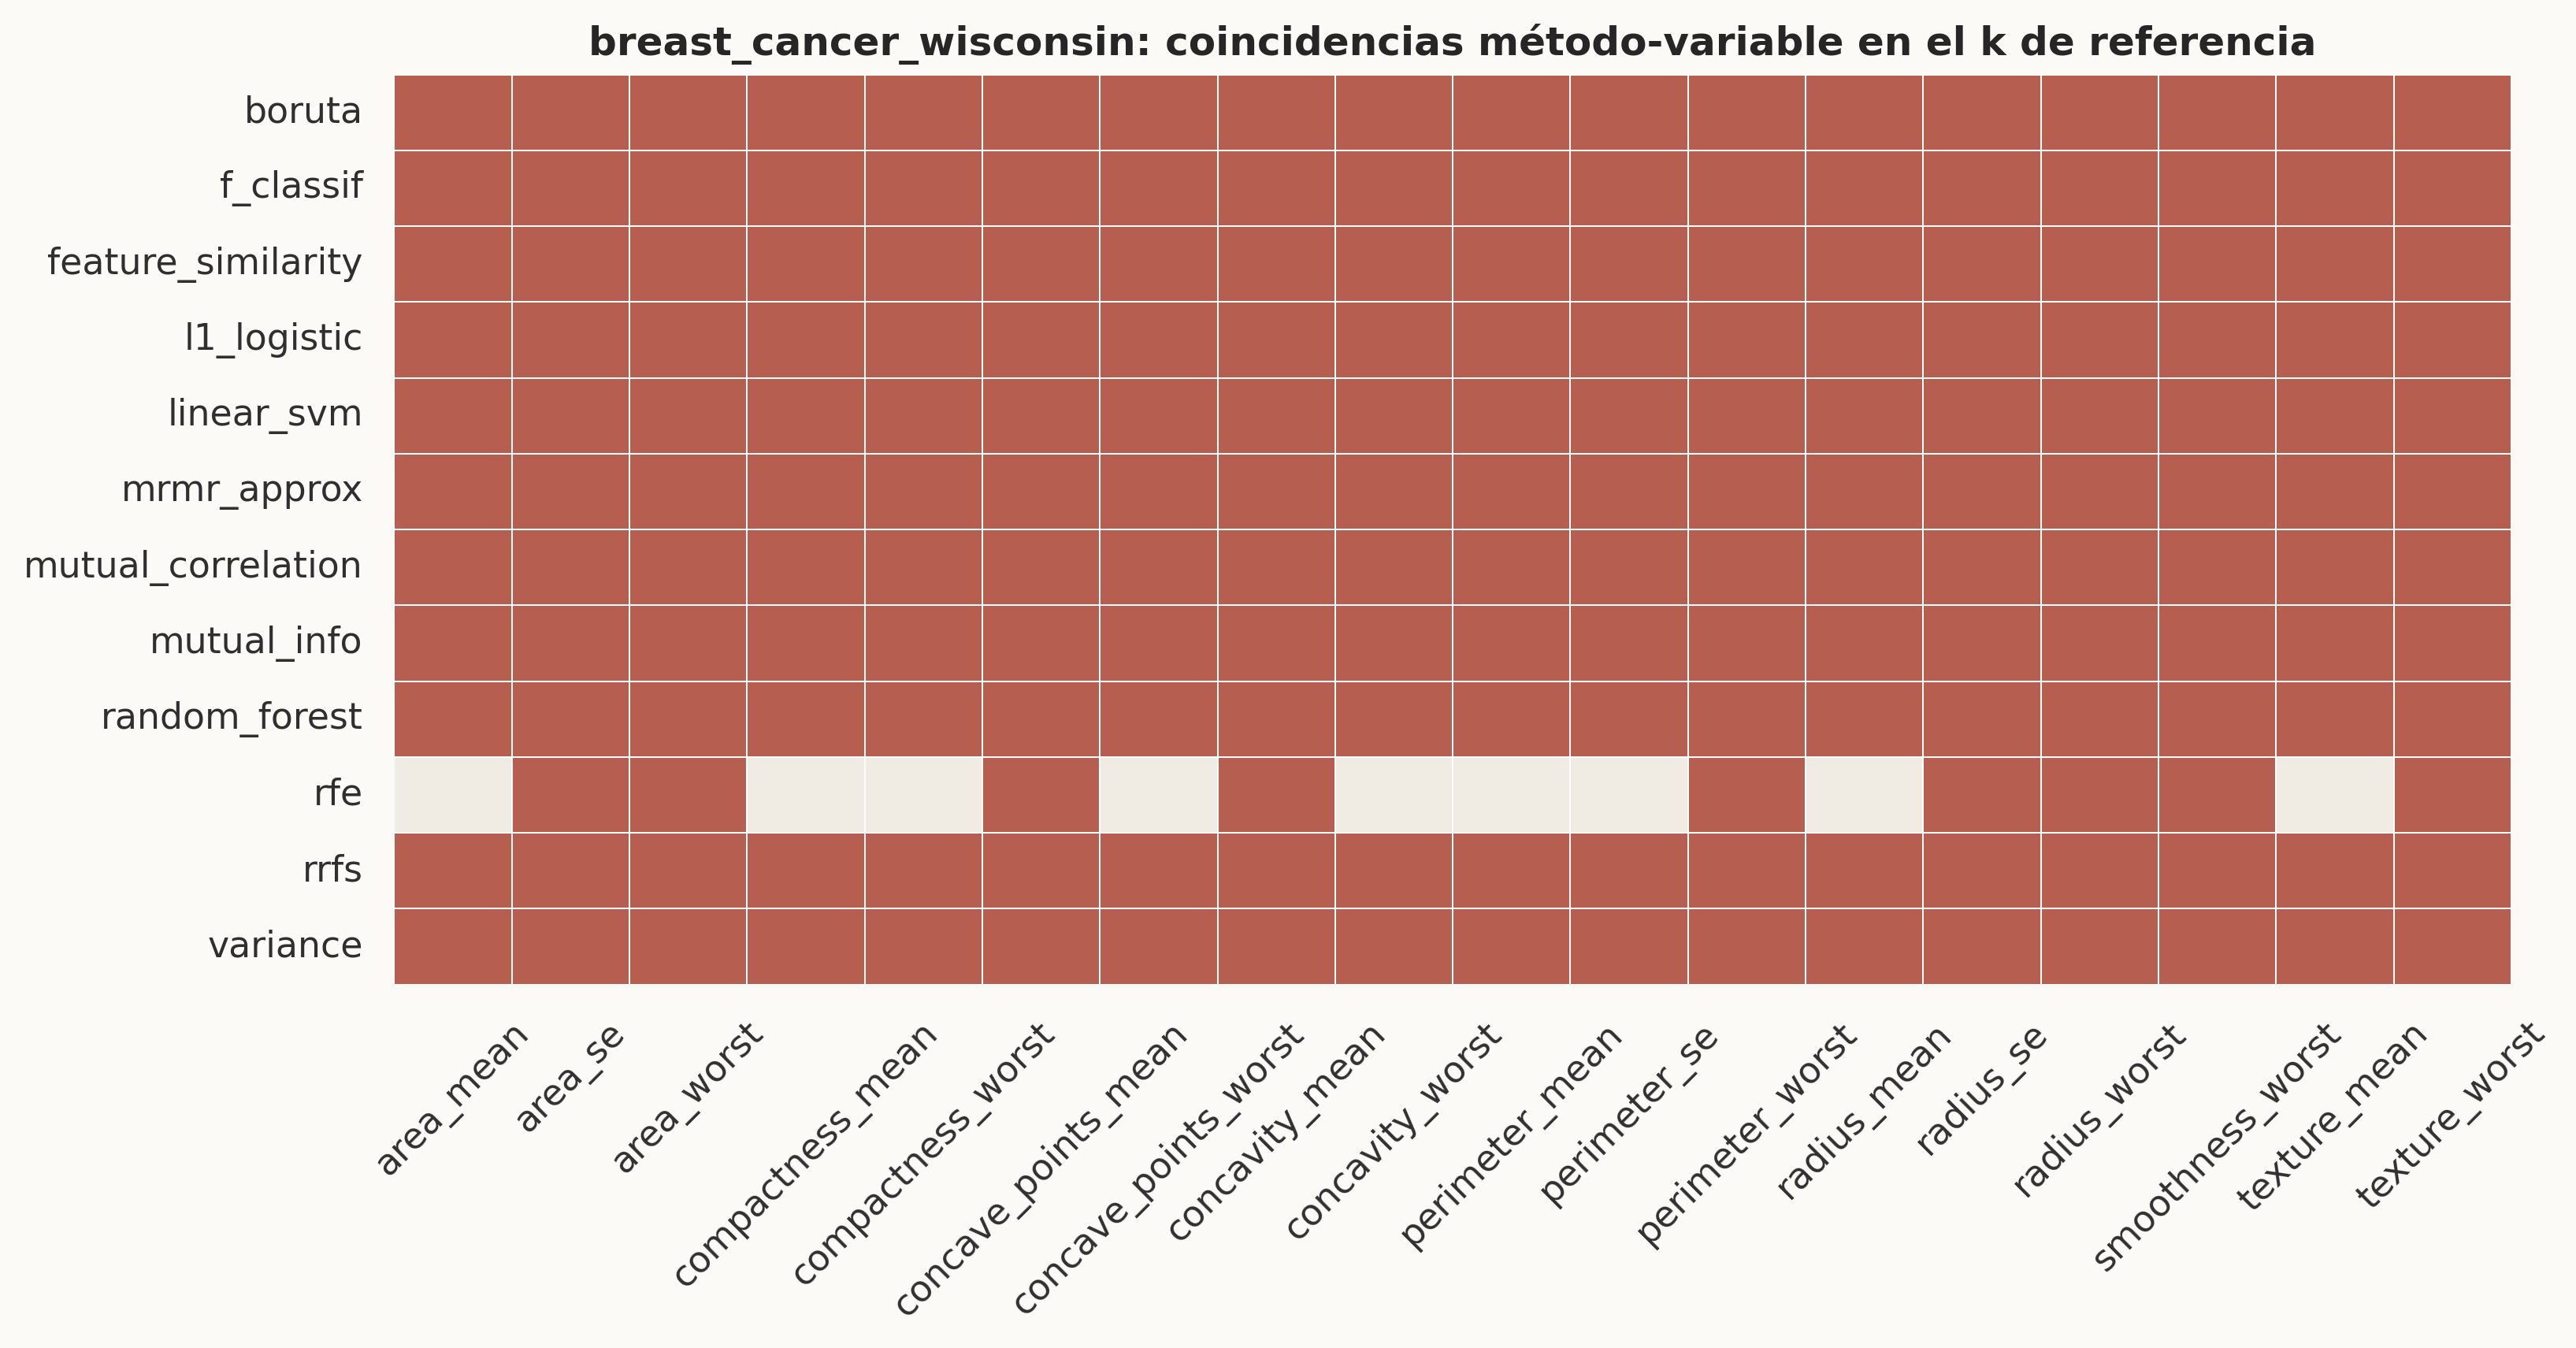

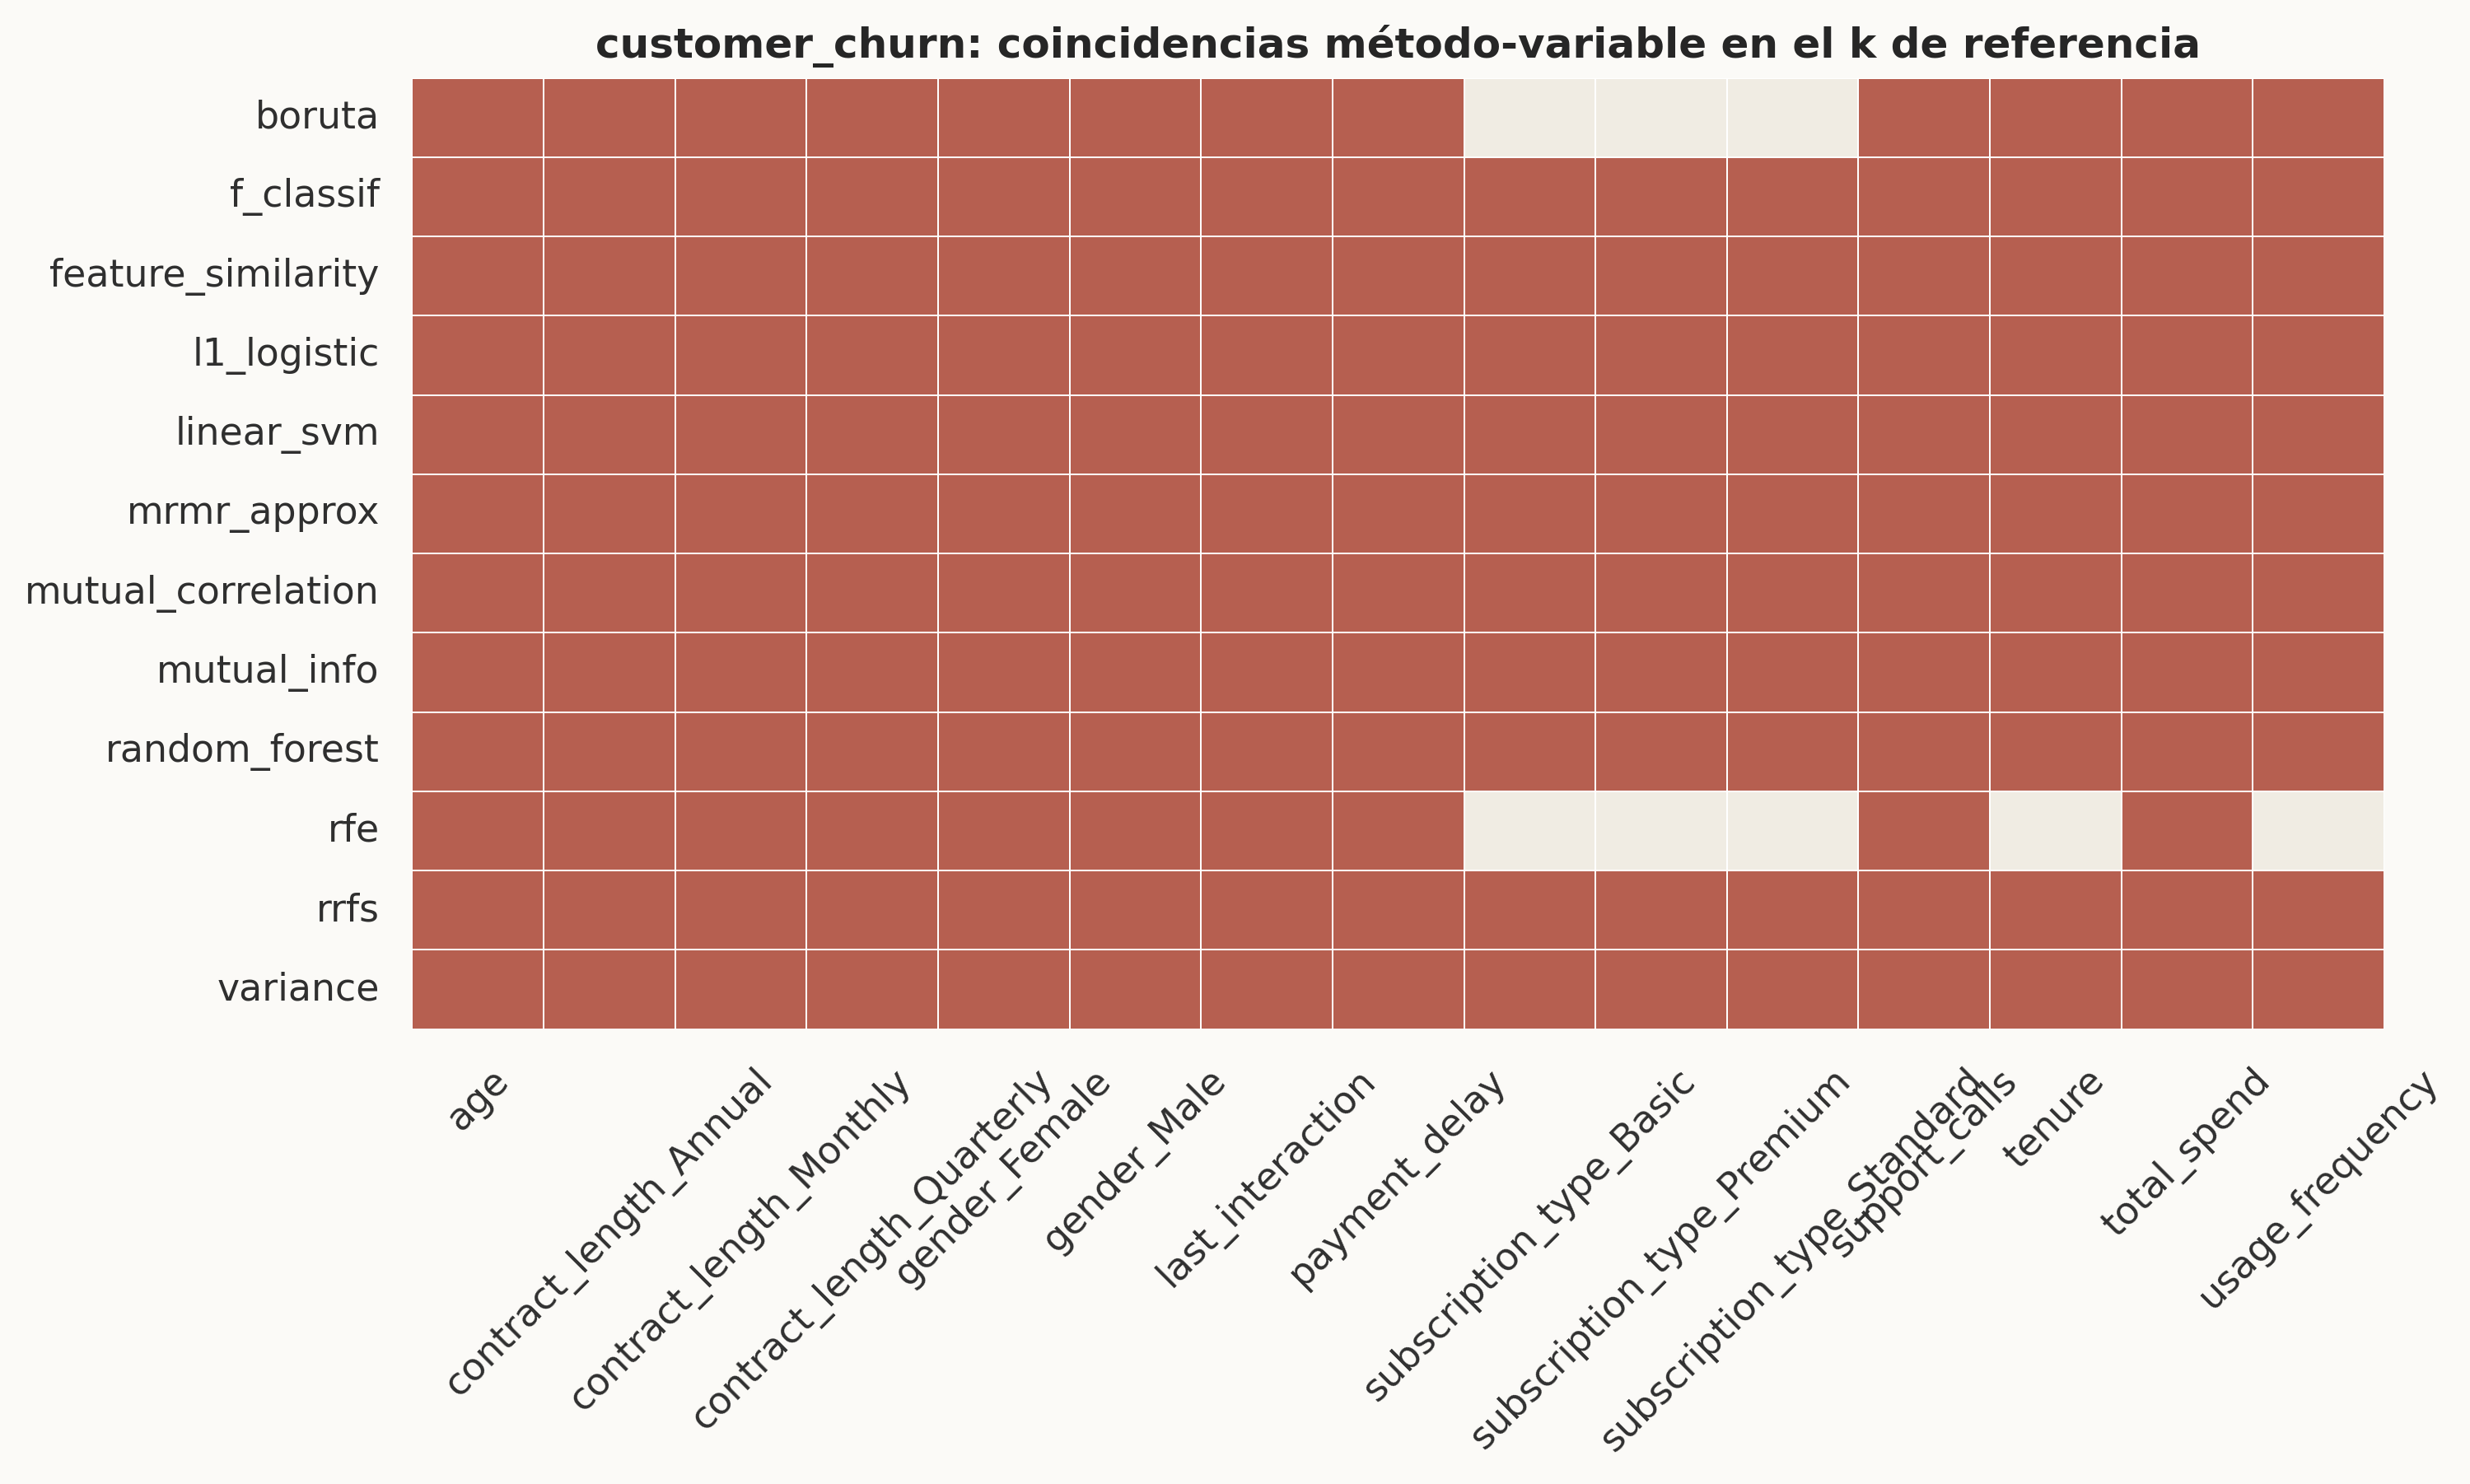

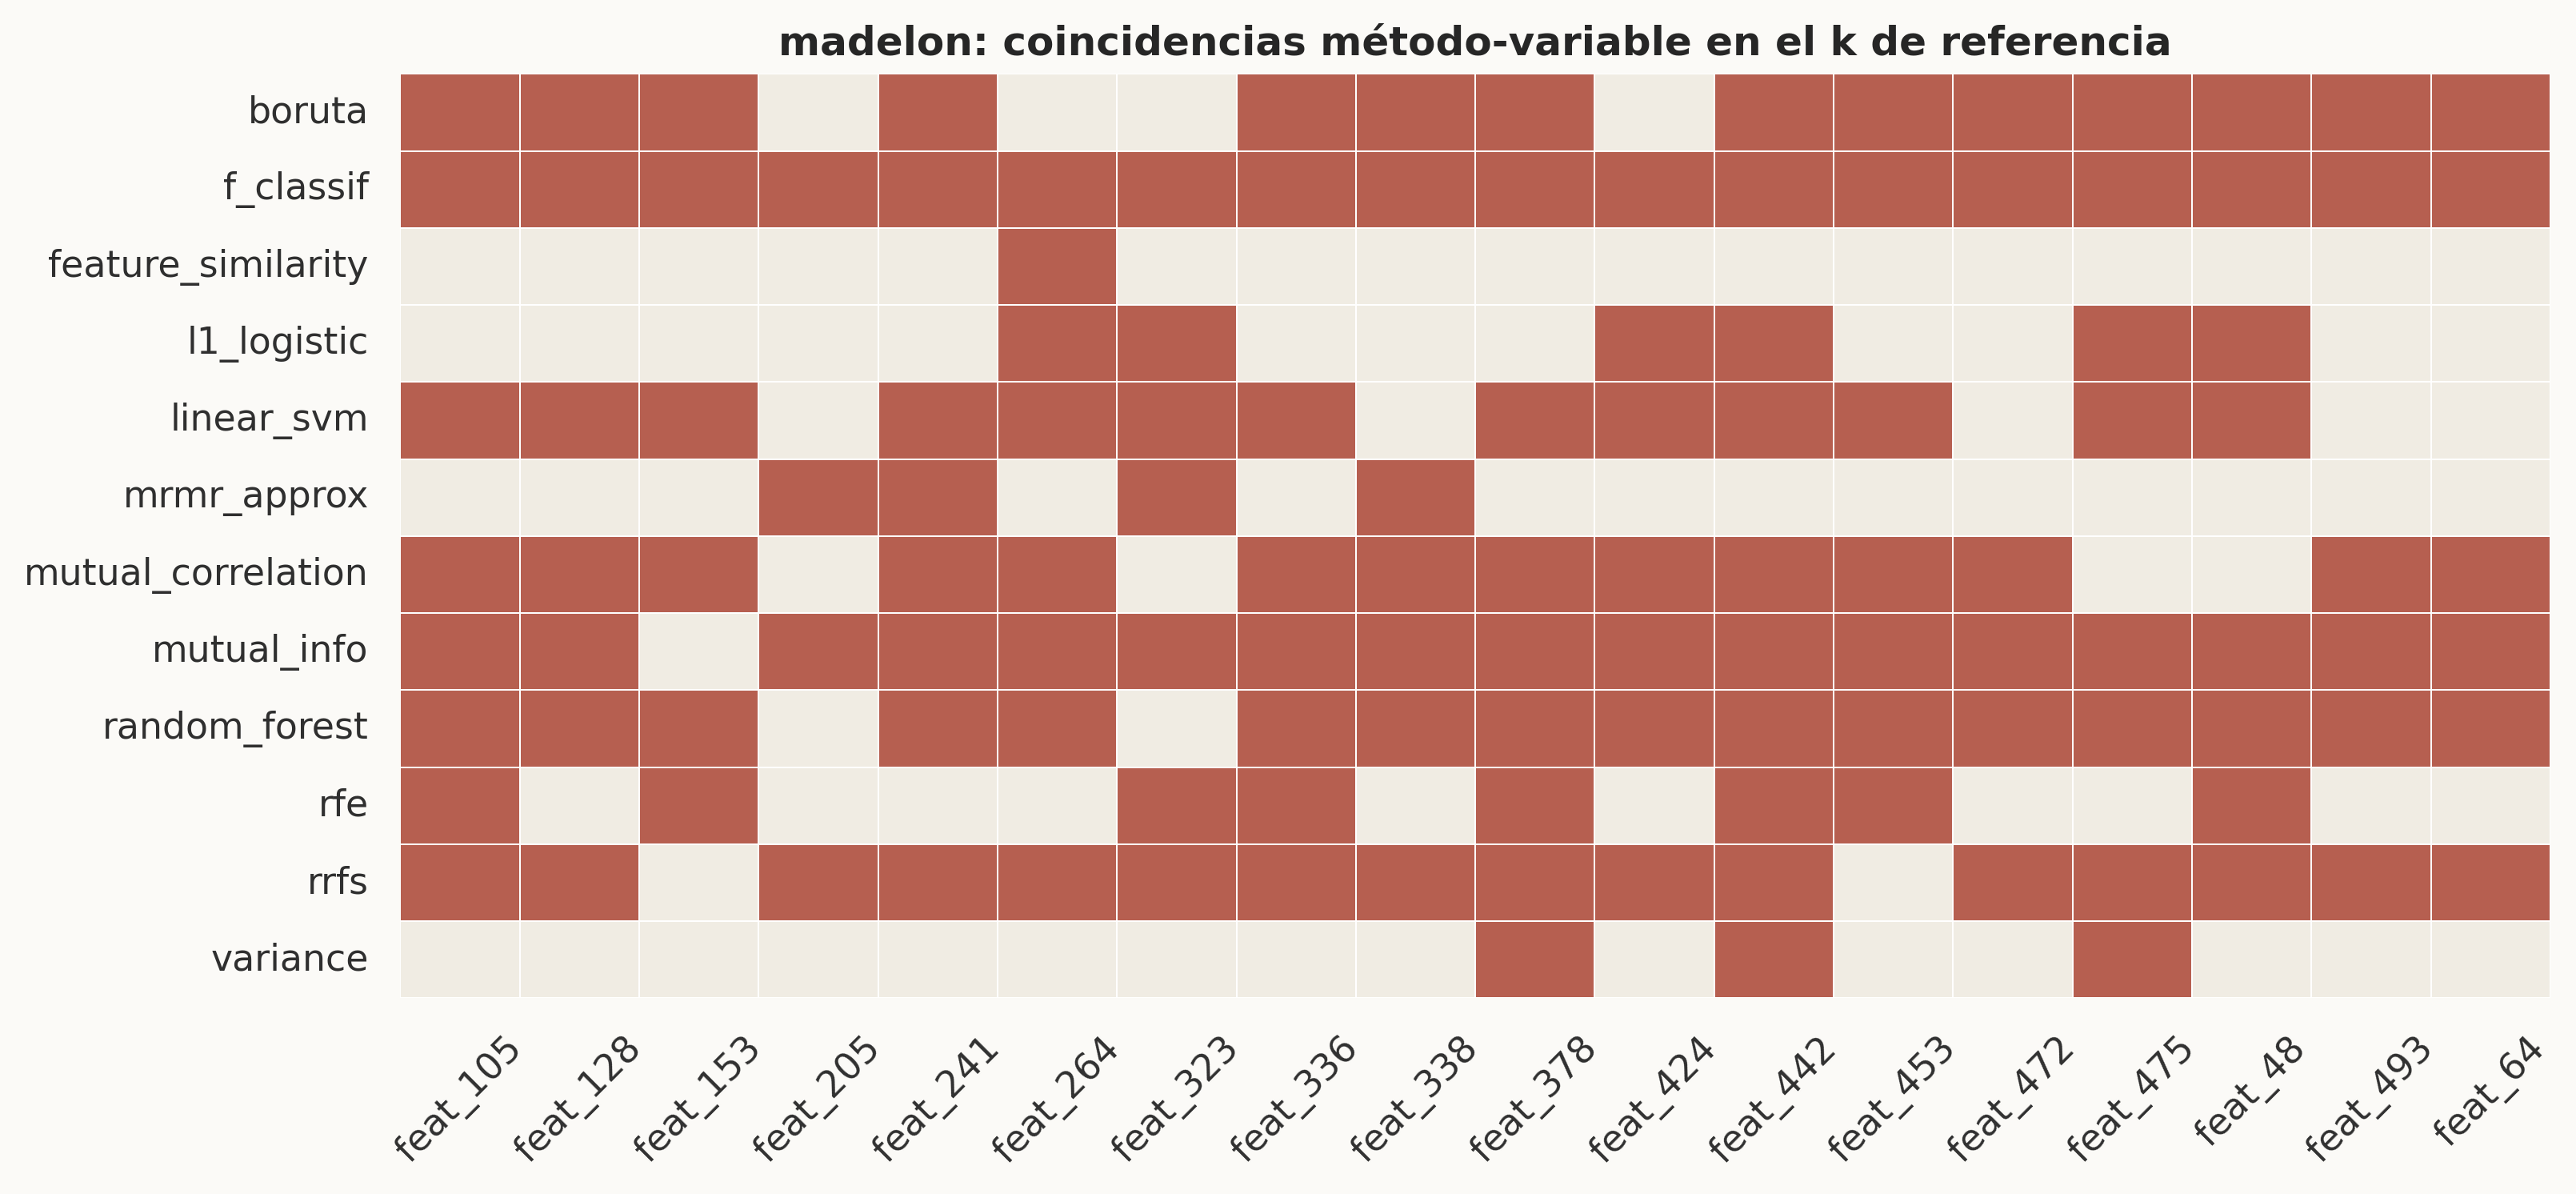

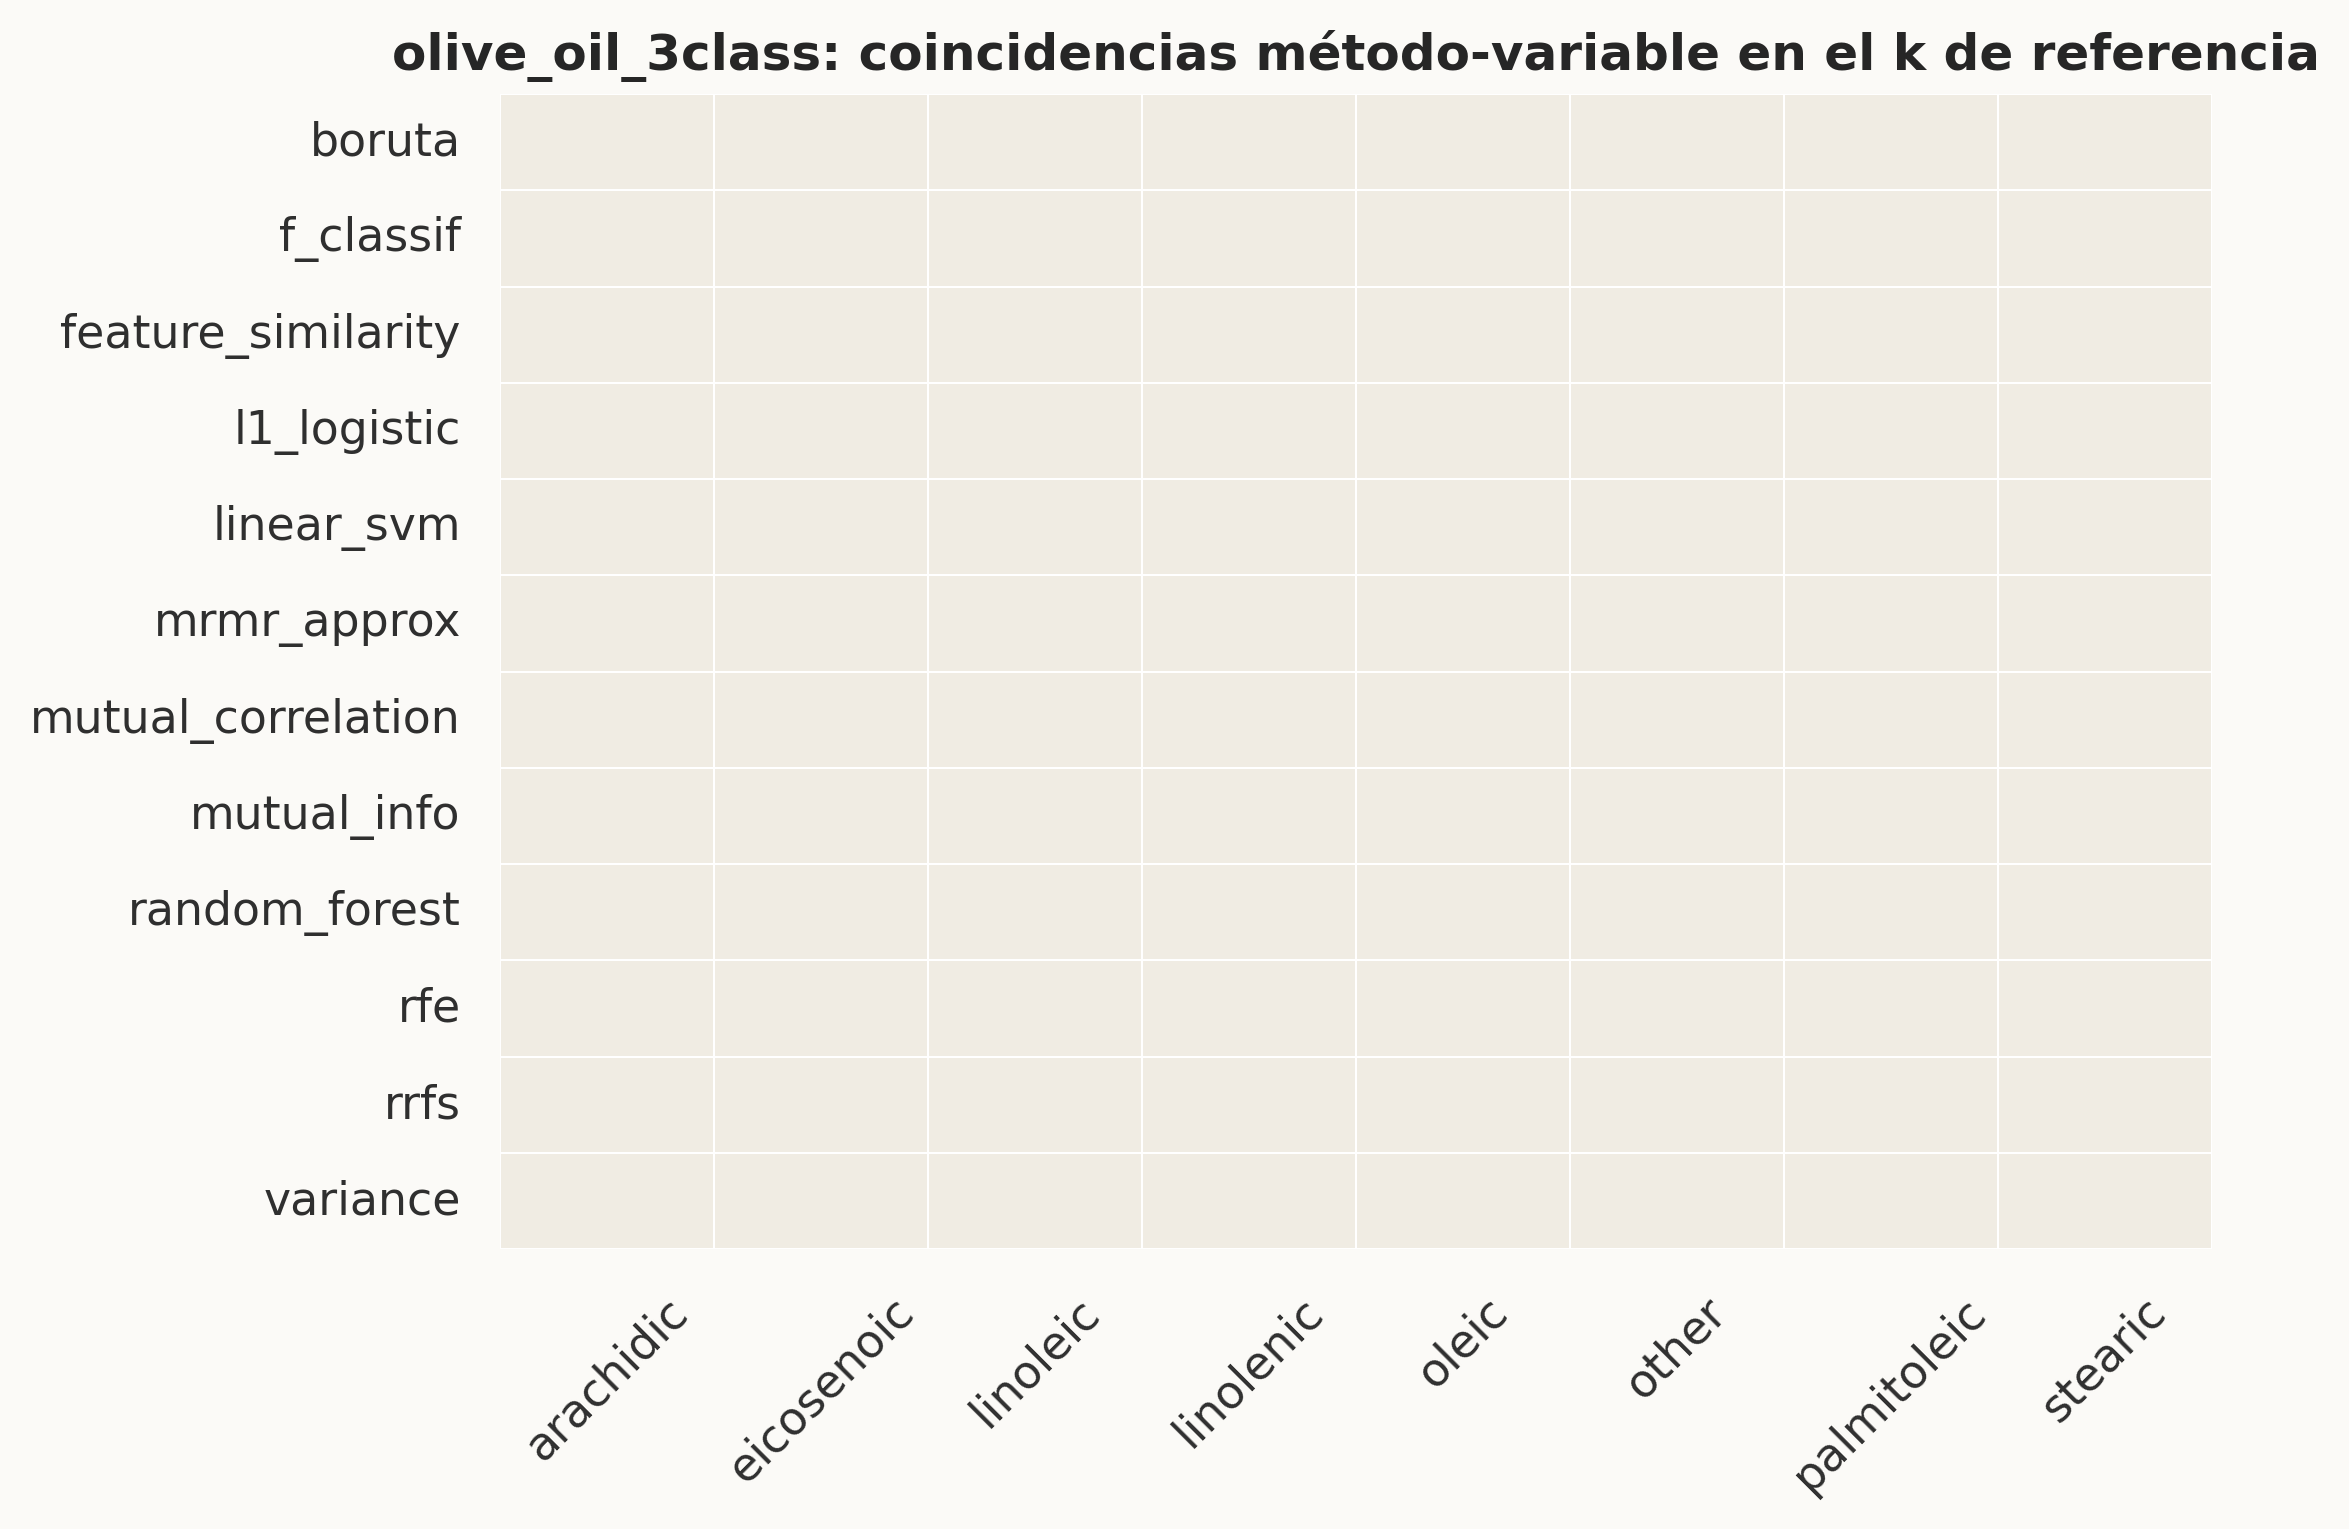

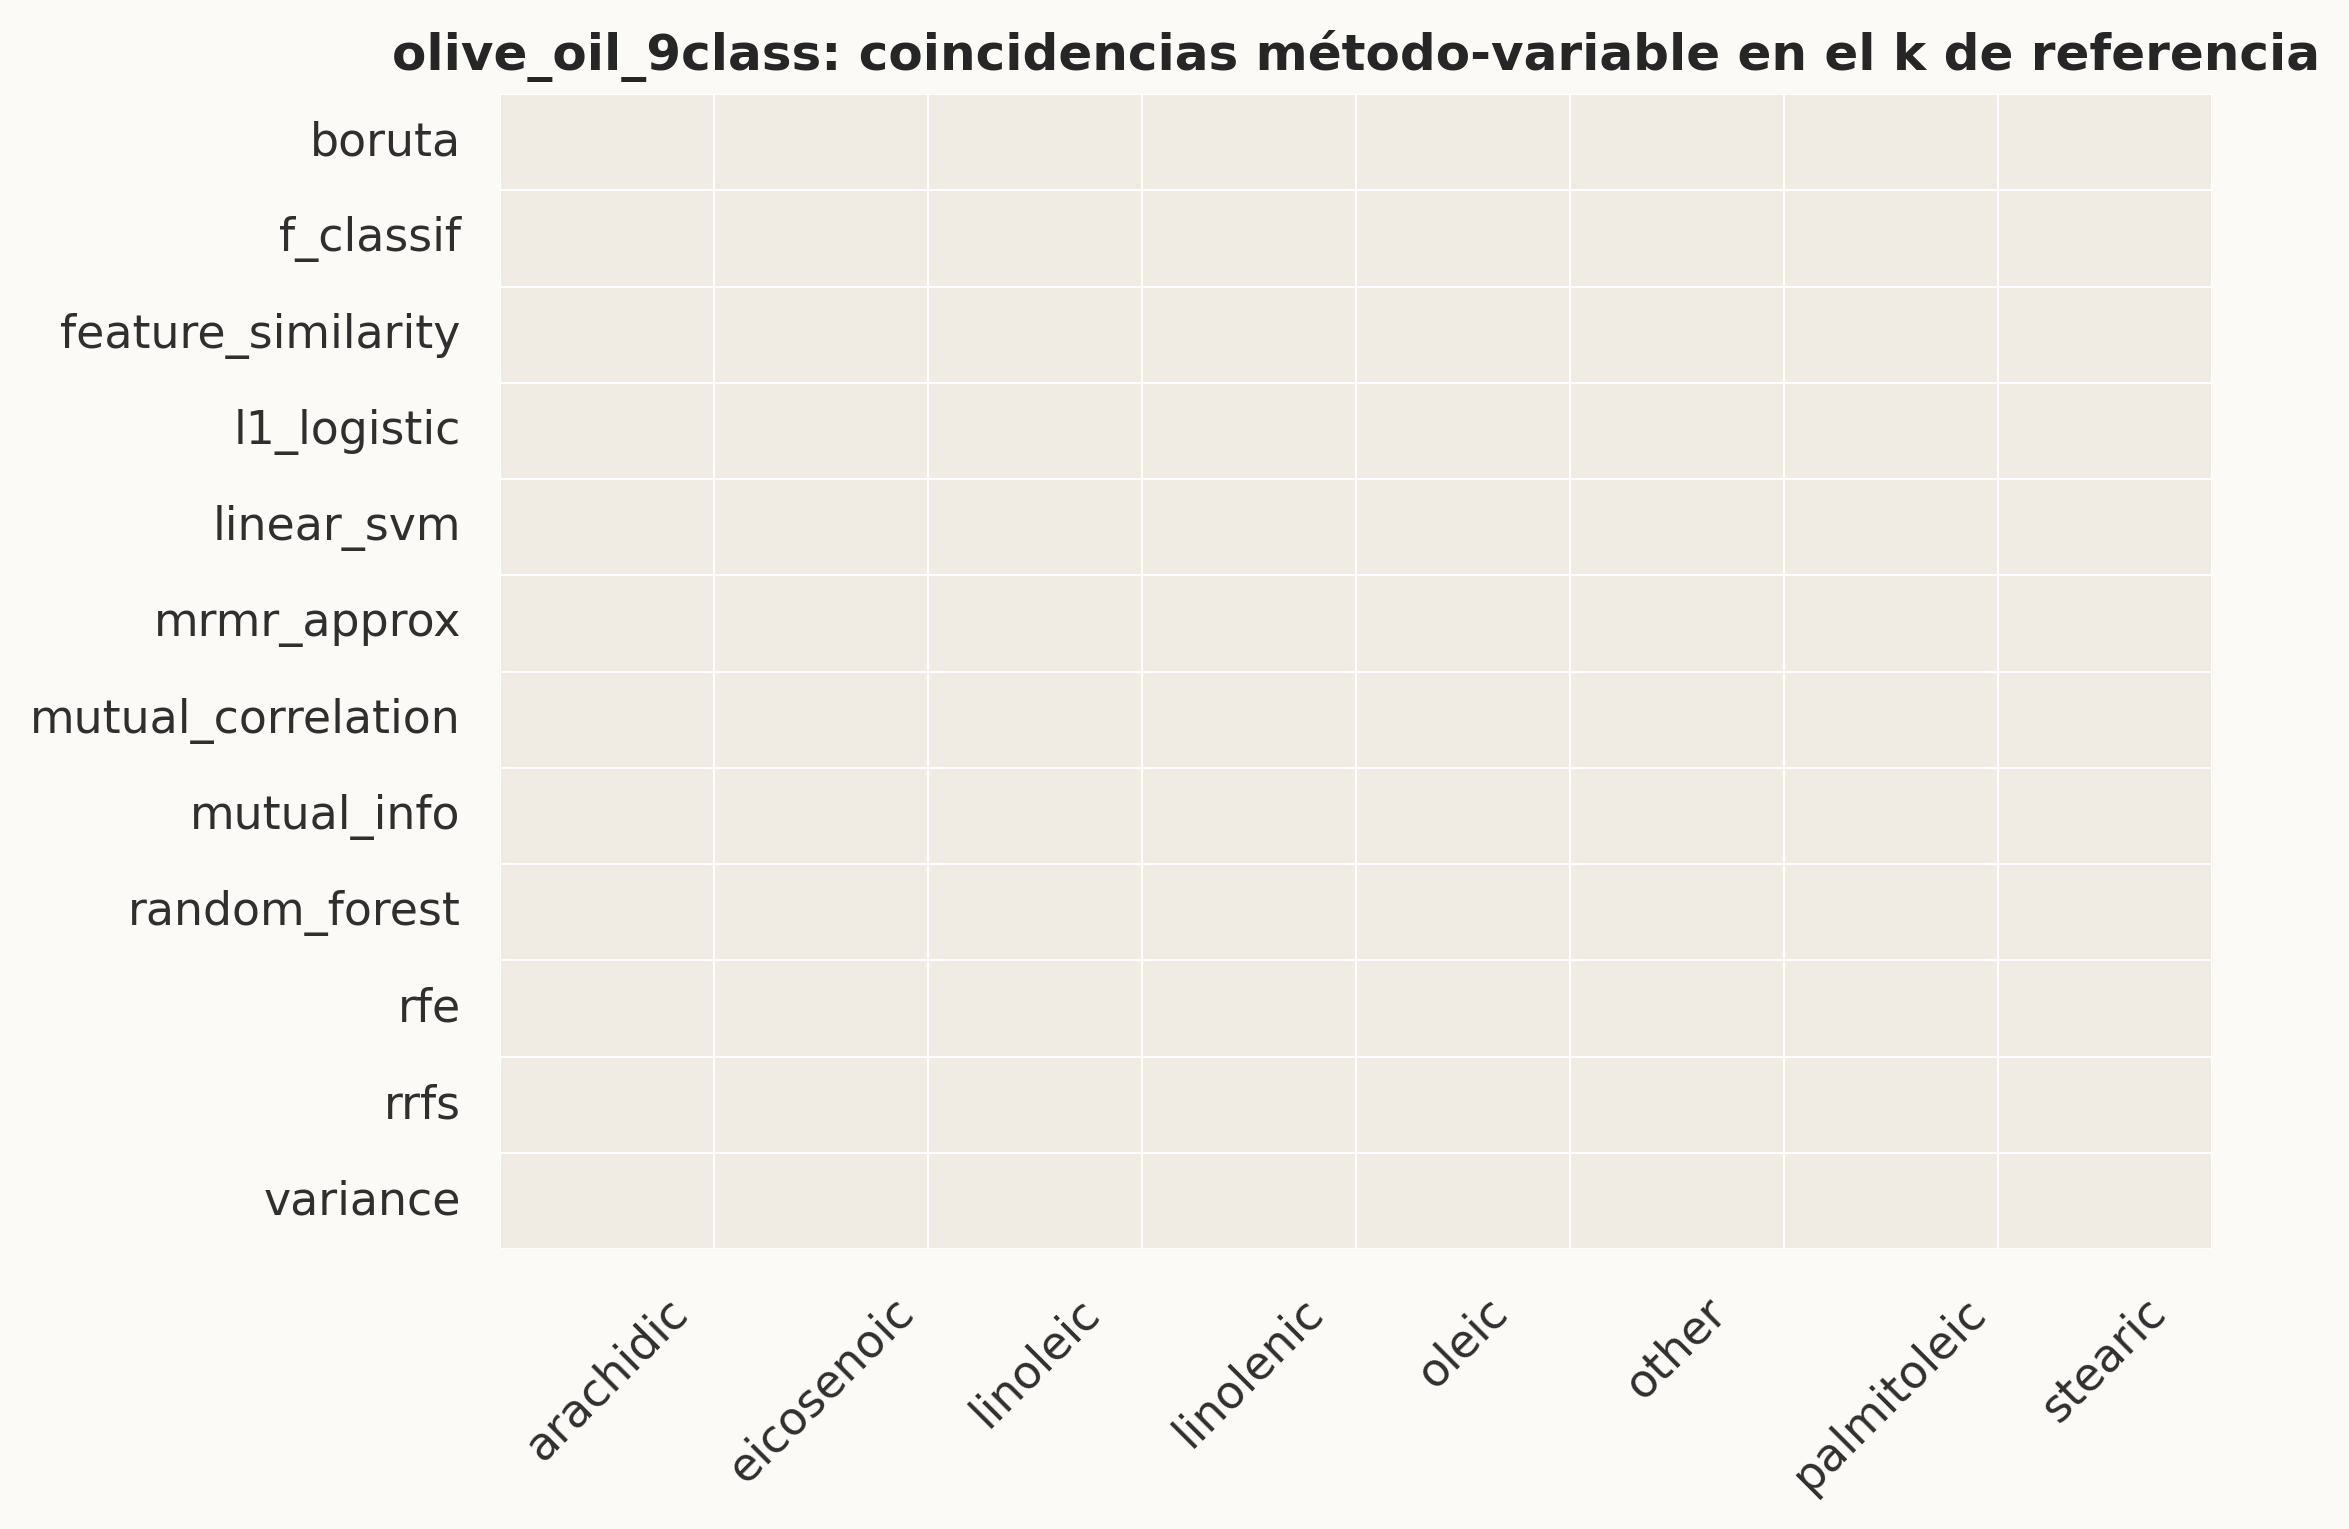

,Dataset,Figura método-variable
0,breast_cancer_wisconsin,results/figures/05_feature_selection/method_feature_heatmaps/breast_cancer_wisconsin_method_feature_heatmap.png
1,customer_churn,results/figures/05_feature_selection/method_feature_heatmaps/customer_churn_method_feature_heatmap.png
2,madelon,results/figures/05_feature_selection/method_feature_heatmaps/madelon_method_feature_heatmap.png
3,olive_oil_3class,results/figures/05_feature_selection/method_feature_heatmaps/olive_oil_3class_method_feature_heatmap.png
4,olive_oil_9class,results/figures/05_feature_selection/method_feature_heatmaps/olive_oil_9class_method_feature_heatmap.png


PosixPath('results/reports/figure_decisions.md')

In [26]:
heatmaps = []
for dataset in fs.DATASETS:
    ruta_heatmap = fs.plot_heatmap_metodo_feature(rankings, dataset)
    heatmaps.append({"dataset": dataset, "ruta": str(ruta_heatmap)})
    figuras.append({"family_id": "fase5_heatmap_metodo_variable", "tier": 0, "question": "¿Qué coincidencias aparecen entre métodos y variables?", "visual_family": "heatmap binario", "decision": "apoyo visual para coincidencias top", "png_path": str(ruta_heatmap)})
    mostrar_png(ruta_heatmap, ancho=760)

tabla_es(pd.DataFrame(heatmaps), {"dataset": "Dataset", "ruta": "Figura método-variable"}, max_filas=10)
fs.registrar_decisiones_figuras(figuras)

Los 5 heatmaps método-variable muestran coincidencias entre selectores sin sustituir las tablas granulares. Su papel es visual: destacar qué variables aparecen en varios métodos, mientras el valor exacto de k y el orden de ranking quedan en las tablas guardadas.

## 5.15 Síntesis para la comparación posterior

La fase termina con perfiles por método: coste medio, estabilidad media y redundancia media seleccionada. Estas cifras no deciden por sí solas qué método es mejor; sirven para que la comparación con QFS sea interpretable por ingrediente: relevancia, redundancia, combinación y optimización.

In [27]:
perfil_tiempo = execution_times.groupby("method", as_index=False).agg(segundos_medios=("elapsed_seconds", "mean"))
perfil_estabilidad = jaccard.groupby("method", as_index=False).agg(jaccard_medio=("jaccard", "mean"))
perfil_redundancia = redundancia.groupby("method", as_index=False).agg(corr_media_seleccionada=("selected_mean_abs_corr", "mean"))
method_profiles = (
    perfil_tiempo
    .merge(perfil_estabilidad, on="method", how="left")
    .merge(perfil_redundancia, on="method", how="left")
    .sort_values("method")
)
fs.guardar_csv(method_profiles, "fs_method_profiles.csv")
tabla_es(
    method_profiles,
    {
        "method": "Método",
        "segundos_medios": "Segundos medios",
        "jaccard_medio": "Jaccard medio",
        "corr_media_seleccionada": "Correlación media seleccionada",
    },
    max_filas=20,
)

,Método,Segundos medios,Jaccard medio,Correlación media seleccionada
0,boruta,6.543,NaN,0.315
1,f_classif,0.006,1.000,0.389
2,feature_similarity,0.106,1.000,0.230
3,l1_logistic,0.195,0.992,0.202
4,linear_svm,0.011,0.991,0.276
5,mrmr_approx,0.265,0.950,0.167
6,mutual_correlation,0.116,1.000,0.365
7,mutual_info,0.102,0.989,0.388
8,random_forest,0.560,0.886,0.384
9,rfe,0.905,1.000,0.297


La síntesis deja 3 ejes de lectura: coste, estabilidad y redundancia. Si QFS mejora a métodos de relevancia pura, el aporte no se atribuye solo a `I_i`; si mejora a métodos de redundancia o mRMR/RRFS, la hipótesis apunta a la combinación global.